# 03 — Modelos estadísticos

## Objetivo

Construir modelos estadísticos de referencia para estimar las principales
componentes del riesgo:

- frecuencia de siniestros;
- severidad;
- prima pura mediante frecuencia × severidad;
- costo agregado mediante un modelo directo.

Estos modelos funcionarán como *baseline* para comparar posteriormente métodos
de Machine Learning y Deep Learning.

La evaluación se realizará sobre una partición de prueba independiente y,
cuando sea posible, también contra las cantidades verdaderas generadas por el
DGP sintético.

Las variables *oracle* se utilizarán exclusivamente para evaluación y nunca
como predictores durante el entrenamiento.

### 1.1 Imports

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
from src.evaluation.metrics import (
    regression_metrics,
    poisson_metrics,
    relative_improvement
)

from src.evaluation.calibration import (
    calibration_by_quantile
)

from src.evaluation.diagnostics import (
    glm_dispersion
)
print(PROJECT_ROOT)
print(sys.path[:3])

c:\Users\derec\Desktop\Proyectos\Modelos_estadisticosvsMLvsDeep-Learning
['c:\\Users\\derec\\Desktop\\Proyectos\\Modelos_estadisticosvsMLvsDeep-Learning', 'c:\\Users\\derec\\anaconda3\\envs\\GLMvsML\\python311.zip', 'c:\\Users\\derec\\anaconda3\\envs\\GLMvsML\\DLLs']


In [23]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

SEED = 42

### 1.2 Carga de datos

In [4]:
DATA_PATH = Path("../data/raw/synthetic_insurance_portfolio.csv")

df = pd.read_csv(DATA_PATH)

print(f"Observaciones: {len(df):,}")
print(f"Variables: {df.shape[1]}")

Observaciones: 10,000
Variables: 15


In [5]:
# Etiquetas categóricas
df["zona_cat"] = df["zona"].map({
    1: "Muy bajo",
    2: "Bajo",
    3: "Medio",
    4: "Alto",
    5: "Muy alto"
})

df["cobertura_cat"] = df["cobertura"].map({
    0: "Limitada",
    1: "RC",
    2: "Amplia"
})

df["tipo_uso_cat"] = df["tipo_uso"].map({
    0: "Particular",
    1: "Transporte privado",
    2: "Carga comercial"
})

### 1.3 Definición de variables

In [6]:
# Variables independientes
FEATURES = [
    "edad",
    "zona",
    "anios_vehiculo",
    "cobertura",
    "historial_siniestros",
    "tipo_uso"
]

# Variables dependientes
TARGET_FREQUENCY = "numero_siniestros"
TARGET_SEVERITY = "severidad_promedio"
TARGET_COST = "costo_siniestros"

# Variables para validar resultados
ORACLE = [
    "lambda_real",
    "prob_siniestro_real",
    "severidad_esperada_real",
    "prima_pura_real"
]

# Validar que ninguna variable oracle puede entrar como predictor
assert not set(FEATURES) & set(ORACLE)

### 1.4 Train/Test split

In [8]:
train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.20,
    random_state=SEED
)

df_train = df.loc[train_idx].copy()
df_test = df.loc[test_idx].copy()

print(f"Train: {len(df_train):,}")
print(f"Test:  {len(df_test):,}")

Train: 8,000
Test:  2,000


In [9]:
# Resumen del split, verificar que las frecuencias sean comparables
split_summary = pd.DataFrame({
    "train": [
        df_train["numero_siniestros"].mean(),
        df_train["tuvo_siniestro"].mean(),
        df_train["costo_siniestros"].mean()
    ],
    "test": [
        df_test["numero_siniestros"].mean(),
        df_test["tuvo_siniestro"].mean(),
        df_test["costo_siniestros"].mean()
    ]
}, index=[
    "frecuencia_media",
    "proporcion_con_siniestro",
    "costo_medio"
])

split_summary

,train,test
frecuencia_media,0.154875,0.157500
proporcion_con_siniestro,0.141375,0.146000
costo_medio,1936.977709,2008.681614


In [10]:
split_df = pd.DataFrame({
    "policy_id": df["policy_id"],
    "split": np.where(
        df.index.isin(train_idx),
        "train",
        "test"
    )
})

split_df.head()

,policy_id,split
0,1,test
1,2,train
2,3,train
3,4,test
4,5,train


In [11]:
SPLIT_PATH = Path("../data/processed/train_test_split.csv")

SPLIT_PATH.parent.mkdir(
    parents=True,
    exist_ok=True
)

split_df.to_csv(
    SPLIT_PATH,
    index=False
)

## 2. Modelo GLM Poisson para frecuencia

La variable `numero_siniestros` representa un conteo no negativo. El análisis
exploratorio mostró además que su media y varianza marginales son similares,
por lo que un modelo Poisson constituye un punto de partida natural.

Se supone que:

$$
N_i \mid X_i \sim Poisson(\lambda_i)
$$

y se utiliza un enlace logarítmico:

$$
\log(\lambda_i)=X_i^\top\beta.
$$

De esta manera:

$$
E[N_i\mid X_i]
=
\lambda_i
=
\exp(X_i^\top\beta).
$$

La exponenciación de los coeficientes permite interpretar los parámetros como
efectos multiplicativos sobre la frecuencia esperada.

In [12]:
# Formula que indica la regresión lineal poisson
formula_poisson_1 = """
numero_siniestros ~
edad +
anios_vehiculo +
C(zona_cat) +
C(cobertura_cat) +
historial_siniestros +
C(tipo_uso_cat)
"""

In [13]:
# Ajuste del GLM Poisson
poisson_1 = smf.glm(
    formula=formula_poisson_1,
    data=df_train,
    family=sm.families.Poisson()
).fit()

print(poisson_1.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:      numero_siniestros   No. Observations:                 8000
Model:                            GLM   Df Residuals:                     7988
Model Family:                 Poisson   Df Model:                           11
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3471.6
Date:              mar., 22 sep. 2026   Deviance:                       4616.4
Time:                        11:24:43   Pearson chi2:                 7.86e+03
No. Iterations:                     6   Pseudo R-squ. (CS):            0.03822
Covariance Type:            nonrobust                                         
                                            coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

### 2.3 Coeficientes como efectos multiplicativos

Una de las grandes ventajas del GLM Poisson con enlace log es:

$$
\log(\lambda) = X\beta
$$

por lo que: 

$$
\lambda = e^{X\beta}
$$

Entonces:

$$
e^{\beta_j}
$$

puede interpretarse como un **factor multiplicativo sobre la frecuencia esperada**, manteniendo lo demás constante.

In [14]:
coef_table = pd.DataFrame({
    "coef": poisson_1.params,
    "exp_coef": np.exp(poisson_1.params),
    "p_value": poisson_1.pvalues
})

coef_table

,coef,exp_coef,p_value
Intercept,-1.743861,0.174844,2.569805e-30
C(zona_cat)[T.Bajo],-0.254291,0.775466,4.602263e-03
C(zona_cat)[T.Medio],-0.226725,0.797140,1.207079e-02
C(zona_cat)[T.Muy alto],0.225852,1.253390,5.072698e-03
C(zona_cat)[T.Muy bajo],-0.449840,0.637730,2.276374e-06
C(cobertura_cat)[T.Limitada],-0.217514,0.804516,2.287038e-03
C(cobertura_cat)[T.RC],-0.188364,0.828313,1.636456e-02
C(tipo_uso_cat)[T.Particular],-0.244790,0.782869,1.343451e-02
C(tipo_uso_cat)[T.Transporte privado],-0.179523,0.835669,7.194929e-02
edad,-0.003776,0.996231,2.991666e-02


De acuerdo al primer ajuste que se realizo, podemos explicar lo siguiente:

- historial_siniestros (Coef: 0.3481 | $p < 0.001$): Por cada siniestro adicional en el historial del cliente, la frecuencia esperada de siniestros aumenta aproximadamente un $41.6\%$ ($\exp(0.3481) - 1$), manteniendose constantes las demás variables.

- anios_vehiculo (Coef: 0.0160 | $p = 0.001$): A mayor antigüedad del vehículo, mayor siniestralidad. Por cada año extra de antigüedad del auto, la frecuencia esperada aumenta un $1.6\%$ ($\exp(0.0160) - 1$).

- edad (Coef: -0.0038 | $p = 0.030$): Bajo la especificación lineal actual, el modelo estima una reducción promedio de aproximadamente $0.38\%$ ($\exp(-0.0038) - 1$) por año. Sin embargo, el EDA sugirió una relación no lineal, por lo que este coeficiente podría estar resumiendo inadecuadamente el efecto real de la edad.

 - zona_cat (Zona de riesgo): La categoría de referencia es "Alto". 
    - Muy alto: Presenta un aumento significativo del riesgo ($+25.3\%$) respecto a la zona de referencia.
    - Muy bajo, Bajo y Medio: Tienen un riesgo significativamente menor (por ejemplo, estar en una zona Muy bajo reduce el riesgo un $36.2\%$ respecto a la zona base).

- cobertura_cat (Tipo de cobertura): Manteniendo constantes las demás variables, las pólizas Limitadas presentan una frecuencia esperada aproximadamente 19.5% inferior a las de cobertura Amplia, mientras que RC presenta una frecuencia aproximadamente 17.2% inferior.

- tipo_uso_cat (Uso del vehículo)La categoría de referencia es "carga comercial".
   - El uso Particular reduce el riesgo un $21.7\%$ ($p = 0.013$).
   - El uso Transporte privado no alcanza significancia estadística del $5\%$ ($p = 0.072$), por lo que no hay suficiente evidencia para rechazar: $H_0: \beta_{\text{Transporte privado}}=0$

#### 2.3.1 Análisis de sobredispersión y Pseudo $R^2$

La dispersión de Pearson de de 0.984, aproximadamente 1 y menor que uno, eso no da una pista de que hay equidispersión, por lo que un modelo Poisson es una gran opción.

Respecto a la pseudo $R^2$ es de 0.038, pero esto tiene sentido ya que, la frecuencia media es de apenas 0.155, hay mucha variabilidad individual dificil de predecir.

Ejemplo:

Dos asegurados con exactamente el mismo $X$ pueden tener:

$$
N_1=0, N_2=1
$$

simplemente por azar.

In [15]:
pearson_dispersion = (
    poisson_1.pearson_chi2 /
    poisson_1.df_resid
)

print(f"Dispersión Pearson φ: {pearson_dispersion:.4f}")
print(f"Pseudo R^2: {0.03822}")

Dispersión Pearson φ: 0.9841
Pseudo R^2: 0.03822


### 2.4 Mejora del modelo: efecto no lineal de edad

En el Análisis explotatorio observamos que:

$$
\text{Frecuencia}\uparrow \text{hasta edades intermedia y después, Frecuencia}\downarrow
$$

Pero el modelo actual impone una recta:

$$
\log(\lambda) = \beta_0 + B_1edad + ...
$$

Pero el comportamiento de edad es similar a una parabola, por lo que haremos:

$$
\text{edad}^2.
$$

Pero primero vamos a restarle media de la edad del portafolio, para evitar problemas de multicolinealidad.


#### Demostración de restar media a una variable evita tener multicolinealidad

Sea $Z = X - \mu_X$, de modo que por construcción $E[Z] = 0$.
Queremos calcular la covarianza entre la variable centrada $Z$ y su cuadrado $Z^2$:

$$\text{Cov}(Z, Z^2) = E[(Z - E[Z])(Z^2 - E[Z^2])]$$

Como $E[Z] = 0$, esto se simplifica a:

$$\text{Cov}(Z, Z^2) = E[Z \cdot (Z^2 - E[Z^2])]$$

$$\text{Cov}(Z, Z^2) = E[Z^3] - E[Z] \cdot E[Z^2]$$

Como $E[Z] = 0$:
$$\text{Cov}(Z, Z^2) = E[Z^3]$$

$E[Z^3]$ es el tercer momento central (relacionado con el sesgo o skewness). Si la distribución de edad es simétrica alrededor de su media, $E[Z^3] = 0$.

Por lo tanto, $\text{Cov}(Z, Z^2) = 0$, haciendo que la correlación sea exactamente 0.

In [16]:
edad_media_train = df_train["edad"].mean()

df_train["edad_c"] = (
    df_train["edad"] - edad_media_train
)

df_test["edad_c"] = (
    df_test["edad"] - edad_media_train
)

df_train["edad_c2"] = df_train["edad_c"] ** 2
df_test["edad_c2"] = df_test["edad_c"] ** 2

In [17]:
formula_poisson_2 = """
numero_siniestros ~
edad_c +
edad_c2 +
anios_vehiculo +
C(zona_cat) +
C(cobertura_cat) +
historial_siniestros +
C(tipo_uso_cat)
"""

In [18]:
poisson_2 = smf.glm(
    formula=formula_poisson_2,
    data=df_train,
    family=sm.families.Poisson()
).fit()

print(poisson_2.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:      numero_siniestros   No. Observations:                 8000
Model:                            GLM   Df Residuals:                     7987
Model Family:                 Poisson   Df Model:                           12
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3463.3
Date:              mar., 22 sep. 2026   Deviance:                       4599.8
Time:                        11:25:03   Pearson chi2:                 7.83e+03
No. Iterations:                     6   Pseudo R-squ. (CS):            0.04022
Covariance Type:            nonrobust                                         
                                            coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

In [19]:
comparison_poisson = pd.DataFrame({
    "Modelo": [
        "Poisson lineal",
        "Poisson + edad²"
    ],
    "LogLik": [
        poisson_1.llf,
        poisson_2.llf
    ],
    "AIC": [
        poisson_1.aic,
        poisson_2.aic
    ],
    "Deviance": [
        poisson_1.deviance,
        poisson_2.deviance
    ],
    "Pearson dispersion": [
        poisson_1.pearson_chi2 / poisson_1.df_resid,
        poisson_2.pearson_chi2 / poisson_2.df_resid
    ]
})

comparison_poisson

,Modelo,LogLik,AIC,Deviance,Pearson dispersion
0,Poisson lineal,-3471.603440,6967.206881,4616.444300,0.984119
1,Poisson + edad²,-3463.288926,6952.577851,4599.815271,0.980739


### Efecto no lineal de la edad

El modelo que incorpora un término cuadrático para la edad presenta una mejora
respecto a la especificación exclusivamente lineal.

El coeficiente asociado con `edad_c2` es negativo y estadísticamente
significativo, lo que indica una relación cóncava entre edad y frecuencia
esperada. La frecuencia aumenta hasta alcanzar un máximo alrededor de las
edades intermedias y posteriormente disminuye.

Este comportamiento es consistente con el patrón identificado previamente
durante el análisis exploratorio.

Además, la inclusión del término cuadrático mejora el log-likelihood y reduce
la devianza y el AIC, mientras que los coeficientes asociados con las demás
variables permanecen prácticamente estables.

Por esta razón, la especificación cuadrática de edad se conservará en el modelo
Poisson de referencia.

In [20]:

y_train_freq = df_train["numero_siniestros"]
y_test_freq = df_test["numero_siniestros"]

pred_train_freq = poisson_2.predict(df_train)
pred_test_freq = poisson_2.predict(df_test)

In [21]:
frequency_calibration = pd.DataFrame({
    "Muestra": ["Train", "Test"],
    "Frecuencia observada": [
        y_train_freq.mean(),
        y_test_freq.mean()
    ],
    "Frecuencia predicha": [
        pred_train_freq.mean(),
        pred_test_freq.mean()
    ]
})

frequency_calibration

,Muestra,Frecuencia observada,Frecuencia predicha
0,Train,0.154875,0.154875
1,Test,0.157500,0.153042


En la muestra de entrenamiento, la frecuencia media observada y la frecuencia
media estimada son prácticamente idénticas. Esta coincidencia se deriva en gran
medida de las propiedades del ajuste del GLM Poisson con intercepto y no implica
que el modelo pueda predecir exactamente los siniestros individuales.

En la muestra de prueba, la frecuencia observada es 0.1575 siniestros por
póliza, mientras que el modelo estima aproximadamente 0.1530. La diferencia es
pequeña, lo que indica una buena calibración agregada fuera de muestra.

Sin embargo, la comparación de medias únicamente evalúa la calibración global.
Para determinar si el modelo discrimina correctamente entre pólizas de
diferente nivel de riesgo es necesario estudiar la calibración a lo largo de
la distribución de las predicciones y utilizar métricas específicas para datos
de conteo.

### 2.5 Evaluación out-of-sample del modelo Poisson

In [24]:
def frequency_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred))
    }

In [25]:
baseline_pred = np.full(
    len(df_test),
    y_train_freq.mean()
)

baseline_metrics = frequency_metrics(
    y_test_freq,
    baseline_pred
)

poisson_metrics = frequency_metrics(
    y_test_freq,
    pred_test_freq
)

pd.DataFrame(
    [baseline_metrics, poisson_metrics],
    index=["Baseline media", "GLM Poisson"]
)

,MAE,RMSE
Baseline media,0.267152,0.397115
GLM Poisson,0.255862,0.390971


### 2.6 Poisson Deviance


In [26]:
from sklearn.metrics import mean_poisson_deviance

In [27]:
poisson_deviance_model = mean_poisson_deviance(
    y_test_freq,
    pred_test_freq
)

poisson_deviance_baseline = mean_poisson_deviance(
    y_test_freq,
    baseline_pred
)

print(
    f"Poisson Deviance - Baseline: "
    f"{poisson_deviance_baseline:.4f}"
)

print(
    f"Poisson Deviance - GLM: "
    f"{poisson_deviance_model:.4f}"
)

Poisson Deviance - Baseline: 0.6152
Poisson Deviance - GLM: 0.5872


In [28]:
deviance_reduction = (
    1
    - poisson_deviance_model
    / poisson_deviance_baseline
)

print(
    f"Reducción relativa de deviance: "
    f"{deviance_reduction:.2%}"
)

Reducción relativa de deviance: 4.56%


### 2.7 Gráfico de calibración

In [29]:
calibration_df = pd.DataFrame({
    "observado": y_test_freq.values,
    "predicho": np.asarray(pred_test_freq)
})

calibration_df["decil_riesgo"] = pd.qcut(
    calibration_df["predicho"],
    q=10,
    duplicates="drop"
)

calibration_by_decile = (
    calibration_df
    .groupby("decil_riesgo", observed=True)
    .agg(
        frecuencia_observada=("observado", "mean"),
        frecuencia_predicha=("predicho", "mean"),
        polizas=("observado", "size")
    )
    .reset_index()
)

calibration_by_decile

,decil_riesgo,frecuencia_observada,frecuencia_predicha,polizas
0,"(0.0393, 0.0793]",0.085,0.068226,200
1,"(0.0793, 0.0924]",0.105,0.085795,200
2,"(0.0924, 0.104]",0.115,0.098234,200
3,"(0.104, 0.116]",0.085,0.109273,200
4,"(0.116, 0.13]",0.130,0.122221,200
5,"(0.13, 0.146]",0.135,0.137198,200
6,"(0.146, 0.168]",0.185,0.156438,200
7,"(0.168, 0.195]",0.180,0.180767,200
8,"(0.195, 0.255]",0.235,0.219961,200
9,"(0.255, 0.821]",0.320,0.352311,200


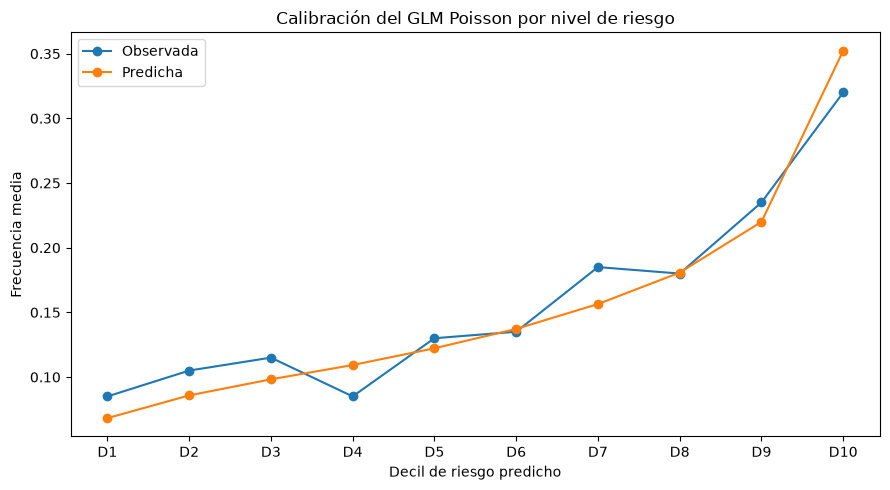

In [30]:
x = np.arange(len(calibration_by_decile))

plt.figure(figsize=(9, 5))

plt.plot(
    x,
    calibration_by_decile["frecuencia_observada"],
    marker="o",
    label="Observada"
)

plt.plot(
    x,
    calibration_by_decile["frecuencia_predicha"],
    marker="o",
    label="Predicha"
)

plt.xticks(
    x,
    [f"D{i}" for i in range(1, len(x) + 1)]
)

plt.xlabel("Decil de riesgo predicho")
plt.ylabel("Frecuencia media")
plt.title("Calibración del GLM Poisson por nivel de riesgo")
plt.legend()

plt.tight_layout()
plt.show()

### Evaluación out-of-sample

El GLM Poisson presenta una mejora respecto al modelo baseline que asigna la
misma frecuencia esperada a todas las pólizas.

El MAE disminuye de aproximadamente 0.267 a 0.256 y el RMSE de 0.397 a 0.391.
La mejora es moderada, lo que refleja la dificultad de predecir realizaciones
individuales de una variable de conteo con una fuerte componente aleatoria.

La Poisson deviance disminuye de 0.6152 a 0.5872, equivalente a una reducción
relativa aproximada de 4.56% frente al baseline. Esto indica que las
características incluidas en el modelo permiten explicar una parte de la
heterogeneidad observada en la frecuencia.

El análisis por deciles muestra además una capacidad razonable para discriminar
entre pólizas de diferente nivel de riesgo. La frecuencia estimada aumenta
progresivamente desde aproximadamente 0.068 en el primer decil hasta 0.352 en
el décimo. La frecuencia observada presenta un patrón general similar, aunque
con fluctuaciones atribuibles a la variabilidad muestral.

En términos generales, el modelo presenta una calibración adecuada, aunque se
observan pequeñas diferencias en algunos segmentos, particularmente en los
extremos de la distribución de riesgo.

Estos resultados sugieren que el GLM Poisson constituye un baseline estadístico
competitivo y correctamente calibrado para la posterior comparación con
modelos de Machine Learning y Deep Learning.

### 2.8 Evaluación contra la frecuencia verdadera (*oracle*)

A diferencia de la evaluación tradicional contra el número de siniestros
observado, en este experimento sintético conocemos la frecuencia verdadera
generada para cada póliza, `lambda_real`.

Esto permite comparar directamente:

$$
\hat{\lambda}_i
$$

con:

$$
\lambda_i^{real}.
$$

En la muestra de prueba, el modelo obtiene:

- MAE *oracle*: 0.0136
- RMSE *oracle*: 0.0179
- Correlación entre frecuencia real y estimada: 0.9814

Estos resultados indican que el GLM Poisson recupera con bastante precisión la
estructura de riesgo utilizada para generar los datos.

El gráfico de frecuencia real contra frecuencia estimada muestra que la mayor
parte de las observaciones se concentra cerca de la línea de predicción
perfecta. Las desviaciones son mayores en algunos niveles de riesgo elevados,
donde también existe una menor cantidad de observaciones.

La diferencia entre los errores obtenidos contra `numero_siniestros` y contra
`lambda_real` es importante. El conteo observado contiene variabilidad aleatoria
propia del proceso Poisson:

$$
N_i \mid X_i \sim Poisson(\lambda_i),
$$

por lo que incluso un modelo que estimara correctamente $(\lambda_i)$ no podría
predecir exactamente la realización individual $(N_i)$.

Por esta razón, el error frente a `lambda_real` permite evaluar de manera más
directa la capacidad del modelo para recuperar la verdadera función de riesgo,
separando el error de modelado de la variabilidad aleatoria inherente al
fenómeno.

In [31]:
lambda_true_test = df_test["lambda_real"]

oracle_mae = mean_absolute_error(
    lambda_true_test,
    pred_test_freq
)

oracle_rmse = np.sqrt(
    mean_squared_error(
        lambda_true_test,
        pred_test_freq
    )
)

print(f"Oracle MAE:  {oracle_mae:.6f}")
print(f"Oracle RMSE: {oracle_rmse:.6f}")

Oracle MAE:  0.013578
Oracle RMSE: 0.017865


In [32]:
oracle_corr = np.corrcoef(
    lambda_true_test,
    pred_test_freq
)[0, 1]

print(
    f"Correlación con lambda real: "
    f"{oracle_corr:.4f}"
)

Correlación con lambda real: 0.9814


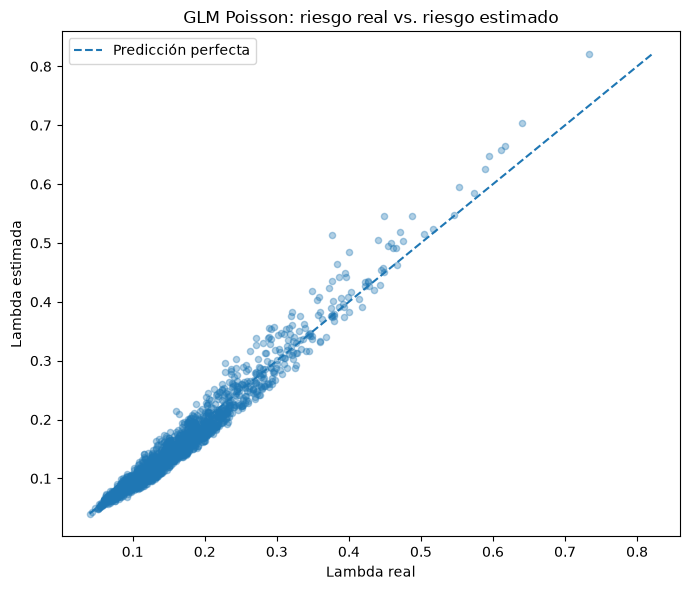

El ajuste es bastante bueno: la mayoría de los puntos están muy cerca de la diagonal. 
Hay algo más de desviación para riesgos altos, donde además tenemos menos observaciones, 
pero el GLM está recuperando muy bien la estructura generadora


In [33]:
plt.figure(figsize=(7, 6))

plt.scatter(
    lambda_true_test,
    pred_test_freq,
    alpha=0.35,
    s=20
)

min_val = min(
    lambda_true_test.min(),
    pred_test_freq.min()
)

max_val = max(
    lambda_true_test.max(),
    pred_test_freq.max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    label="Predicción perfecta"
)

plt.xlabel("Lambda real")
plt.ylabel("Lambda estimada")
plt.title("GLM Poisson: riesgo real vs. riesgo estimado")
plt.legend()

plt.tight_layout()
plt.show()
print("El ajuste es bastante bueno: la mayoría de los puntos están muy cerca de la diagonal. \n" \
"Hay algo más de desviación para riesgos altos, donde además tenemos menos observaciones, \n" \
"pero el GLM está recuperando muy bien la estructura generadora")

### Consideración metodológica

La evaluación contra `lambda_real` únicamente es posible porque el conjunto de
datos fue generado de manera sintética y el proceso generador es conocido.

En un problema real, la frecuencia esperada individual:

$$
\lambda_i = E[N_i \mid X_i]
$$

es una cantidad latente que no puede observarse directamente. Para cada póliza
solo se dispone del número de siniestros efectivamente ocurrido durante el
período analizado.

Por este motivo, en aplicaciones reales la calidad del modelo debe evaluarse
de manera indirecta mediante métricas out-of-sample, devianza, calibración y
comparaciones entre siniestros observados y esperados en grupos suficientemente
grandes de pólizas.

La disponibilidad de una variable *oracle* constituye una de las principales
ventajas del diseño sintético de este proyecto, ya que permitirá comparar de
forma controlada qué tan bien los modelos estadísticos, de Machine Learning y
de Deep Learning recuperan la verdadera estructura subyacente del riesgo.

### Conclusión del modelo de frecuencia

El GLM Poisson presenta un desempeño satisfactorio como modelo estadístico de
referencia.

La incorporación de un término cuadrático para la edad mejora la especificación
del modelo y permite representar la relación no lineal detectada durante el
análisis exploratorio. Los demás coeficientes son estables y presentan efectos
consistentes con los patrones observados previamente.

Los diagnósticos de dispersión no muestran evidencia relevante de
sobredispersión residual, mientras que la evaluación out-of-sample indica una
mejora moderada frente a un modelo baseline y una calibración razonable a lo
largo de los distintos niveles de riesgo.

Finalmente, la evaluación contra la frecuencia verdadera muestra que el modelo
recupera con elevada precisión la función generadora del riesgo, con una
correlación de aproximadamente 0.98 entre la frecuencia real y la estimada.

Por estas razones, este GLM Poisson se conservará como el baseline estadístico
de frecuencia para la posterior comparación con modelos de Machine Learning y
Deep Learning.

## 3. Modelo de severidad

### 3.1 Cargar el dataset de siniestros

In [34]:
CLAIMS_PATH = Path(
    "../data/raw/synthetic_insurance_claims.csv"
)

SPLIT_PATH = Path(
    "../data/processed/train_test_split.csv"
)

df_claims = pd.read_csv(CLAIMS_PATH)
split_df = pd.read_csv(SPLIT_PATH)

print(f"Siniestros totales: {len(df_claims):,}")

df_claims.head()

Siniestros totales: 1,554


,claim_id,policy_id,claim_number,edad,zona,anios_vehiculo,cobertura,historial_siniestros,tipo_uso,severidad,severidad_esperada_real
0,1,9,1,29,5,14,0,1,1,4433.688779,11150.615755
1,2,11,1,48,4,7,0,0,0,3579.689213,9276.596481
2,3,14,1,61,4,7,1,0,1,4795.235856,13296.418603
3,4,18,1,25,4,3,2,0,1,8081.880601,18164.964675
4,5,18,2,25,4,3,2,0,1,8610.168138,18164.964675


Heredamos el split mediante policy_id

In [35]:
df_claims = df_claims.merge(
    split_df,
    on="policy_id",
    how="left"
)

assert df_claims["split"].notna().all()

claims_train = df_claims.loc[
    df_claims["split"] == "train"
].copy()

claims_test = df_claims.loc[
    df_claims["split"] == "test"
].copy()

print(f"Train claims: {len(claims_train):,}")
print(f"Test claims:  {len(claims_test):,}")

Train claims: 1,239
Test claims:  315


### 3.2 Etiquetas categóricas.

In [36]:
for data in [claims_train, claims_test]:

    data["zona_cat"] = data["zona"].map({
        1: "Muy bajo",
        2: "Bajo",
        3: "Medio",
        4: "Alto",
        5: "Muy alto"
    })

    data["cobertura_cat"] = data["cobertura"].map({
        0: "Limitada",
        1: "RC",
        2: "Amplia"
    })

    data["tipo_uso_cat"] = data["tipo_uso"].map({
        0: "Particular",
        1: "Transporte privado",
        2: "Carga comercial"
    })

### 3.3 GLM Gamma con enlace logarítmico

La severidad representa una variable continua, estrictamente positiva y
asimétrica a la derecha. A partir de los resultados obtenidos durante el EDA,
la distribución Gamma constituye una alternativa natural dentro de la familia
de Modelos Lineales Generalizados.

Se supone:

$$
Z_i \mid X_i \sim Gamma(\mu_i,\phi),
$$

utilizando un enlace logarítmico:

$$
\log(\mu_i)=X_i^\top\beta.
$$

Por tanto:

$$
E[Z_i\mid X_i]
=
\exp(X_i^\top\beta).
$$

El enlace log garantiza predicciones positivas y permite interpretar los
coeficientes de manera multiplicativa sobre la severidad esperada.

In [37]:
formula_gamma_1 = """
severidad ~
edad +
anios_vehiculo +
C(zona_cat) +
C(cobertura_cat) +
historial_siniestros +
C(tipo_uso_cat)
"""

In [38]:
gamma_1 = smf.glm(
    formula=formula_gamma_1,
    data=claims_train,
    family=sm.families.Gamma(
        link=sm.families.links.Log()
    )
).fit()

print(gamma_1.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              severidad   No. Observations:                 1239
Model:                            GLM   Df Residuals:                     1227
Model Family:                   Gamma   Df Model:                           11
Link Function:                    Log   Scale:                         0.32981
Method:                          IRLS   Log-Likelihood:                -12459.
Date:              mar., 22 sep. 2026   Deviance:                       354.56
Time:                        12:13:19   Pearson chi2:                     405.
No. Iterations:                    11   Pseudo R-squ. (CS):             0.3086
Covariance Type:            nonrobust                                         
                                            coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

### 3.4 Tabla de efectos multiplicativos

In [39]:
gamma_coef_table = pd.DataFrame({
    "coef": gamma_1.params,
    "exp_coef": np.exp(gamma_1.params),
    "change_pct": (
        np.exp(gamma_1.params) - 1
    ) * 100,
    "p_value": gamma_1.pvalues
})

gamma_coef_table

,coef,exp_coef,change_pct,p_value
Intercept,9.827565,18537.753189,1.853675e+06,0.000000e+00
C(zona_cat)[T.Bajo],-0.305767,0.736559,-2.634414e+01,3.248361e-09
C(zona_cat)[T.Medio],-0.128995,0.878978,-1.210219e+01,1.307137e-02
C(zona_cat)[T.Muy alto],0.085342,1.089090,8.908993e+00,6.647089e-02
C(zona_cat)[T.Muy bajo],-0.394486,0.674026,-3.259738e+01,6.712082e-13
C(cobertura_cat)[T.Limitada],-0.641778,0.526356,-4.736442e+01,7.693664e-55
C(cobertura_cat)[T.RC],-0.317696,0.727824,-2.721759e+01,1.941489e-12
C(tipo_uso_cat)[T.Particular],-0.185033,0.831076,-1.689235e+01,1.143632e-03
C(tipo_uso_cat)[T.Transporte privado],-0.168516,0.844918,-1.550819e+01,3.312329e-03
edad,0.001024,1.001024,1.024315e-01,3.325612e-01


### Interpretación del GLM Gamma

El modelo Gamma recupera relaciones consistentes con los patrones identificados
durante el análisis exploratorio.

La zona presenta un efecto general creciente sobre la severidad. Las zonas
Muy bajo, Bajo y Medio muestran severidades esperadas inferiores a la zona
Alta. La zona Muy alta presenta una severidad estimada aproximadamente 8.9%
superior, aunque esta diferencia particular no resulta estadísticamente
significativa al nivel del 5%.

La cobertura presenta uno de los efectos más importantes. Manteniendo las
demás características constantes, la cobertura Limitada presenta una
severidad esperada aproximadamente 47.4% inferior a la cobertura Amplia,
mientras que RC presenta una reducción aproximada de 27.2%.

El tipo de uso también contiene información relevante. Los vehículos
Particulares y de Transporte privado presentan severidades esperadas
aproximadamente 16.9% y 15.5% inferiores, respectivamente, a los vehículos de
Carga comercial.

La antigüedad del vehículo presenta un efecto positivo y estadísticamente
significativo. Cada año adicional de antigüedad está asociado con un incremento
aproximado de 1.74% en la severidad esperada.

En contraste, la edad del asegurado y el historial de siniestros no presentan
evidencia de una asociación estadísticamente significativa con la severidad
una vez controlados los demás factores.

Este último resultado resulta particularmente relevante al compararlo con el
modelo de frecuencia, donde el historial de siniestros constituía uno de los
principales factores explicativos. Esto confirma que las variables asociadas
con la ocurrencia de siniestros no necesariamente son las mismas que explican
su magnitud.

### 3.5 Gamma reducido

In [40]:
formula_gamma_2 = """
severidad ~
anios_vehiculo +
C(zona_cat) +
C(cobertura_cat) +
C(tipo_uso_cat)
"""

In [41]:
gamma_2 = smf.glm(
    formula=formula_gamma_2,
    data=claims_train,
    family=sm.families.Gamma(
        link=sm.families.links.Log()
    )
).fit()

print(gamma_2.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              severidad   No. Observations:                 1239
Model:                            GLM   Df Residuals:                     1229
Model Family:                   Gamma   Df Model:                            9
Link Function:                    Log   Scale:                         0.32934
Method:                          IRLS   Log-Likelihood:                -12459.
Date:              mar., 22 sep. 2026   Deviance:                       354.96
Time:                        12:26:17   Pearson chi2:                     405.
No. Iterations:                    10   Pseudo R-squ. (CS):             0.3083
Covariance Type:            nonrobust                                         
                                            coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

In [42]:
gamma_comparison = pd.DataFrame({
    "Modelo": [
        "Gamma completo",
        "Gamma reducido"
    ],
    "LogLik": [
        gamma_1.llf,
        gamma_2.llf
    ],
    "AIC": [
        gamma_1.aic,
        gamma_2.aic
    ],
    "Deviance": [
        gamma_1.deviance,
        gamma_2.deviance
    ],
    "Scale": [
        gamma_1.scale,
        gamma_2.scale
    ],
    "Df Model": [
        gamma_1.df_model,
        gamma_2.df_model
    ]
})

gamma_comparison

,Modelo,LogLik,AIC,Deviance,Scale,Df Model
0,Gamma completo,-12458.919631,24941.839261,354.561317,0.329809,11
1,Gamma reducido,-12459.368015,24938.736030,354.963964,0.329343,9


In [43]:
from scipy.stats import chi2

lr_stat = 2 * (
    gamma_1.llf - gamma_2.llf
)

df_diff = (
    gamma_1.df_model
    - gamma_2.df_model
)

lr_pvalue = chi2.sf(
    lr_stat,
    df_diff
)

print(f"LR statistic: {lr_stat:.4f}")
print(f"df difference: {df_diff}")
print(f"p-value: {lr_pvalue:.4f}")

LR statistic: 0.8968
df difference: 2
p-value: 0.6387


### Selección de la especificación Gamma

Se comparó el modelo Gamma completo con una especificación reducida que excluye
`edad` e `historial_siniestros`.

La eliminación de ambas variables produce cambios mínimos en el log-likelihood,
la devianza y el parámetro de dispersión. Además, el modelo reducido presenta un
AIC menor, lo que favorece una especificación más parsimoniosa.

La prueba de razón de verosimilitudes produce:

$$
LR = 0.8968,\qquad p = 0.6387.
$$

Por lo tanto, no existe evidencia suficiente para concluir que la inclusión
conjunta de `edad` e `historial_siniestros` mejore significativamente el ajuste
del modelo de severidad.

Este resultado es consistente con el análisis exploratorio, donde ninguna de
estas variables mostró una relación clara con la severidad.

En consecuencia, el modelo Gamma reducido se conservará como modelo de
referencia para severidad.

### 3.6 Evaluación out-of-sample del GLM Gamma

In [44]:
# Hacemos las predicciones
gamma_final = gamma_2

y_train_sev = claims_train["severidad"]
y_test_sev = claims_test["severidad"]

pred_train_sev_gamma = gamma_final.predict(claims_train)
pred_test_sev_gamma = gamma_final.predict(claims_test)

#### 3.6.1 Calibración agregada

El GLM Gamma presenta una buena calibración agregada tanto en entrenamiento como
en prueba.

En la muestra de entrenamiento, la severidad media observada es aproximadamente
$12,507, mientras que la severidad media predicha es $12,478, lo que representa
una diferencia relativa de apenas -0.23%.

En la muestra de prueba, la severidad observada es aproximadamente $12,754 y la
predicha $12,657, equivalente a una diferencia relativa de -0.76%.

Por lo tanto, el modelo reproduce adecuadamente el nivel medio de severidad en
datos no utilizados durante el ajuste. La pequeña diferencia observada en test
sugiere una ligera subestimación agregada.

In [45]:
severity_calibration = pd.DataFrame({
    "Muestra": ["Train", "Test"],
    "Severidad observada": [
        y_train_sev.mean(),
        y_test_sev.mean()
    ],
    "Severidad predicha": [
        pred_train_sev_gamma.mean(),
        pred_test_sev_gamma.mean()
    ]
})

severity_calibration["Diferencia relativa"] = (
    severity_calibration["Severidad predicha"]
    / severity_calibration["Severidad observada"]
    - 1
)

severity_calibration

,Muestra,Severidad observada,Severidad predicha,Diferencia relativa
0,Train,12506.716444,12478.039156,-0.002293
1,Test,12753.534055,12657.215718,-0.007552


#### 3.6.2 Baseline

Para evaluar si las características del riesgo aportan capacidad predictiva,
se comparó el GLM Gamma contra un modelo baseline que asigna a todos los
siniestros la severidad media observada en la muestra de entrenamiento.

Los resultados obtenidos son:

| Modelo | MAE | RMSE |
|---|---:|---:|
| Baseline media | 6,869.54 | 10,308.07 |
| GLM Gamma | 5,689.12 | 8,821.83 |

El GLM Gamma reduce el MAE aproximadamente 17.18% y el RMSE 14.42% respecto al
baseline.

Esto indica que las variables explicativas contienen información relevante para
discriminar entre siniestros de distinta severidad esperada.

La mejora del RMSE es ligeramente menor que la del MAE. Esto es consistente con
la elevada variabilidad de la severidad y la presencia de siniestros de gran
magnitud, ya que el RMSE penaliza de forma más intensa los errores grandes.

Por lo tanto, el modelo no solo reproduce adecuadamente la severidad promedio,
sino que también mejora de manera sustancial respecto a una predicción que
ignora las características individuales del riesgo.

In [46]:
baseline_severity = np.full(
    len(claims_test),
    y_train_sev.mean()
)

In [47]:
baseline_severity_metrics = regression_metrics(
    y_test_sev,
    baseline_severity
)

gamma_metrics = regression_metrics(
    y_test_sev,
    pred_test_sev_gamma
)

severity_metrics = pd.DataFrame(
    [
        baseline_severity_metrics,
        gamma_metrics
    ],
    index=[
        "Baseline media",
        "GLM Gamma"
    ]
)

severity_metrics

,MAE,RMSE
Baseline media,6869.537765,10308.071382
GLM Gamma,5689.121329,8821.826163


In [48]:
mae_improvement = relative_improvement(
    baseline_severity_metrics["MAE"],
    gamma_metrics["MAE"]
)

rmse_improvement = relative_improvement(
    baseline_severity_metrics["RMSE"],
    gamma_metrics["RMSE"]
)

print(f"Mejora MAE:  {mae_improvement:.2%}")
print(f"Mejora RMSE: {rmse_improvement:.2%}")

Mejora MAE:  17.18%
Mejora RMSE: 14.42%


#### 3.6.3 Gamma deviance

La Gamma deviance permite evaluar el modelo utilizando una función de pérdida
coherente con la distribución asumida para la severidad.

El modelo baseline obtiene una deviance media de 0.4684, mientras que el GLM
Gamma reduce este valor a 0.3172.

Esto corresponde a una reducción relativa de aproximadamente 32.29%.

La mejora es considerablemente mayor que la observada mediante MAE y RMSE, lo
que indica que el GLM representa de manera adecuada la estructura multiplicativa
y heterocedástica característica de una variable Gamma.

En conjunto, este resultado proporciona evidencia de que la especificación
Gamma aporta una mejora relevante frente a un modelo que asigna la misma
severidad esperada a todos los siniestros.

In [49]:
from sklearn.metrics import mean_gamma_deviance

In [50]:
gamma_deviance_baseline = mean_gamma_deviance(
    y_test_sev,
    baseline_severity
)

gamma_deviance_model = mean_gamma_deviance(
    y_test_sev,
    pred_test_sev_gamma
)

gamma_deviance_reduction = relative_improvement(
    gamma_deviance_baseline,
    gamma_deviance_model
)

print(
    f"Gamma Deviance - Baseline: "
    f"{gamma_deviance_baseline:.4f}"
)

print(
    f"Gamma Deviance - GLM: "
    f"{gamma_deviance_model:.4f}"
)

print(
    f"Reducción relativa de deviance: "
    f"{gamma_deviance_reduction:.2%}"
)

Gamma Deviance - Baseline: 0.4684
Gamma Deviance - GLM: 0.3172
Reducción relativa de deviance: 32.29%


#### 3.6.4 Calibración por nivel de riesgo

La calibración por quintiles muestra que el modelo presenta una capacidad clara
para discriminar entre siniestros de diferente nivel de severidad.

La severidad observada aumenta de manera progresiva desde aproximadamente
$7,731 en el primer quintil hasta $21,806 en el quintil de mayor riesgo. Este
comportamiento confirma que las predicciones del modelo ordenan correctamente
los riesgos desde segmentos de baja hasta alta severidad esperada.

La calibración dentro de los grupos es razonable, aunque no perfecta.

En el primer quintil la diferencia entre severidad observada y predicha es
pequeña. En los quintiles segundo y tercero el modelo tiende a sobreestimar,
siendo la diferencia más importante en el tercer quintil. Por el contrario, en
los dos quintiles de mayor riesgo se observa cierta subestimación.

Estas diferencias deben interpretarse con cautela debido al reducido número de
observaciones por grupo y a la elevada variabilidad individual de la severidad.
Un número relativamente pequeño de siniestros de gran magnitud puede modificar
considerablemente la media observada de un quintil.

En términos generales, el modelo muestra una buena capacidad de discriminación
y una calibración razonable a lo largo de los distintos niveles de riesgo.

In [51]:
severity_calibration_groups = calibration_by_quantile(
    y_test_sev,
    pred_test_sev_gamma,
    n_quantiles=5
)

severity_calibration_groups

,grupo_riesgo,observado_medio,predicho_medio,observaciones
0,"(5671.9039999999995, 8529.151]",7731.275535,7529.035348,65
1,"(8529.151, 10563.431]",8958.062004,9659.599959,61
2,"(10563.431, 12661.547]",9792.170017,11589.544013,63
3,"(12661.547, 16810.049]",15519.001067,14592.249819,63
4,"(16810.049, 24205.675]",21806.107253,19983.286421,63


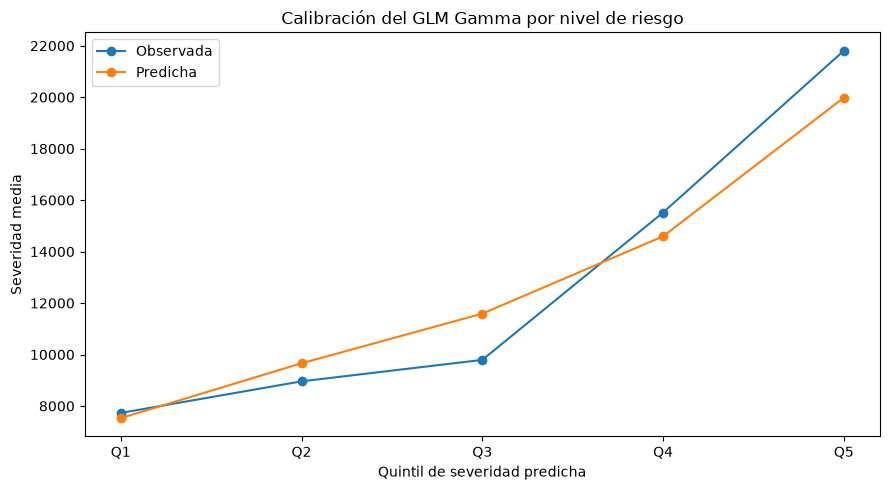

In [52]:
x = np.arange(
    len(severity_calibration_groups)
)

plt.figure(figsize=(9, 5))

plt.plot(
    x,
    severity_calibration_groups["observado_medio"],
    marker="o",
    label="Observada"
)

plt.plot(
    x,
    severity_calibration_groups["predicho_medio"],
    marker="o",
    label="Predicha"
)

plt.xticks(
    x,
    [f"Q{i}" for i in range(1, len(x) + 1)]
)

plt.xlabel("Quintil de severidad predicha")
plt.ylabel("Severidad media")
plt.title(
    "Calibración del GLM Gamma por nivel de riesgo"
)

plt.legend()
plt.tight_layout()
plt.show()

### 3.7 Evaluación contra la severidad verdadera (*oracle*)

Al tratarse de un experimento sintético, se conoce la severidad esperada
verdadera asociada con las características de cada riesgo:

$$
E[Z_i\mid X_i].
$$

Esto permite evaluar directamente la capacidad del GLM Gamma para recuperar la
función de severidad utilizada por el proceso generador.

En la muestra de prueba se obtienen:

- MAE *oracle*: aproximadamente $697;
- RMSE *oracle*: aproximadamente $1,044;
- correlación entre severidad esperada real y estimada: 0.9826.

Estos errores son considerablemente inferiores a los obtenidos al comparar las
predicciones con las severidades efectivamente observadas.

La diferencia se explica porque la severidad observada contiene una importante
componente aleatoria. Incluso si se conociera exactamente la severidad esperada
de una póliza, el costo de un siniestro particular podría encontrarse muy por
encima o por debajo de dicho valor.

Por tanto, la comparación contra el *oracle* permite separar la variabilidad
aleatoria inherente a los siniestros del error atribuible al modelo.

La elevada correlación y la concentración de los puntos alrededor de la línea
de predicción perfecta indican que el GLM Gamma recupera con bastante precisión
la estructura subyacente de la severidad esperada.

In [53]:
severity_true_test = (
    claims_test["severidad_esperada_real"]
)

oracle_severity_metrics = regression_metrics(
    severity_true_test,
    pred_test_sev_gamma
)

oracle_severity_corr = np.corrcoef(
    severity_true_test,
    pred_test_sev_gamma
)[0, 1]

print(
    f"Oracle MAE: "
    f"${oracle_severity_metrics['MAE']:,.2f}"
)

print(
    f"Oracle RMSE: "
    f"${oracle_severity_metrics['RMSE']:,.2f}"
)

print(
    f"Correlación oracle: "
    f"{oracle_severity_corr:.4f}"
)

Oracle MAE: $696.65
Oracle RMSE: $1,043.53
Correlación oracle: 0.9826


Aunque el ajuste global frente al *oracle* es elevado, el gráfico muestra una
mayor dispersión y cierta tendencia a subestimar algunos de los riesgos de
severidad más alta.

Esto sugiere que la especificación GLM podría no capturar completamente algunas
estructuras más complejas presentes en la función de riesgo.

Dado que estas desviaciones se identifican utilizando información *oracle*, no
se utilizarán para modificar la especificación del modelo. En cambio, servirán
como referencia para evaluar posteriormente si modelos más flexibles de Machine
Learning y Deep Learning consiguen recuperar mejor estas estructuras.

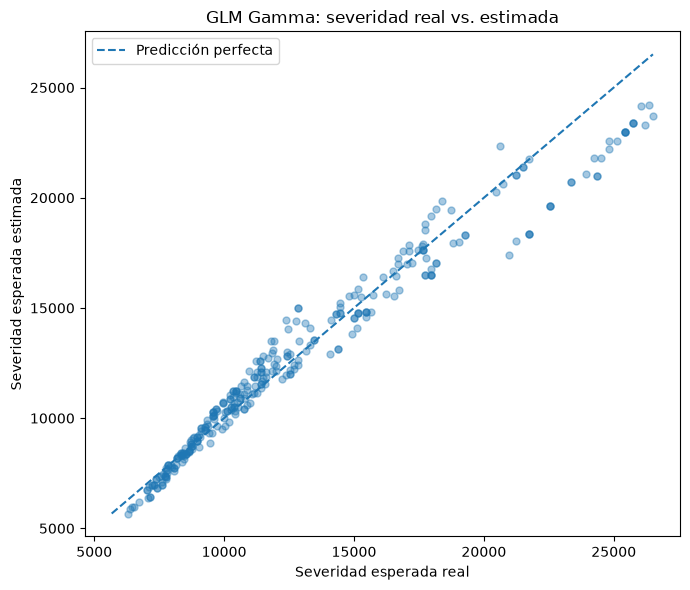

In [54]:
plt.figure(figsize=(7, 6))

plt.scatter(
    severity_true_test,
    pred_test_sev_gamma,
    alpha=0.4,
    s=25
)

min_val = min(
    severity_true_test.min(),
    pred_test_sev_gamma.min()
)

max_val = max(
    severity_true_test.max(),
    pred_test_sev_gamma.max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    label="Predicción perfecta"
)

plt.xlabel("Severidad esperada real")
plt.ylabel("Severidad esperada estimada")
plt.title(
    "GLM Gamma: severidad real vs. estimada"
)

plt.legend()
plt.tight_layout()
plt.show()

### Conclusión del GLM Gamma

El GLM Gamma reducido constituye un baseline estadístico sólido para la
modelación de severidad.

El modelo identifica efectos interpretables y consistentes con los patrones
encontrados durante el análisis exploratorio. Zona, cobertura, tipo de uso y
antigüedad del vehículo aportan información relevante, mientras que edad e
historial de siniestros no justificaron su inclusión en la especificación final.

En datos de prueba, el modelo presenta una buena calibración agregada y mejora
el MAE, RMSE y Gamma deviance respecto a un modelo baseline que ignora las
características del riesgo.

La calibración por quintiles muestra además una clara capacidad para discriminar
entre segmentos de baja y alta severidad esperada.

Finalmente, la evaluación contra la severidad verdadera del DGP muestra una
correlación de aproximadamente 0.98 entre los valores reales y estimados y
errores considerablemente menores que los obtenidos contra las realizaciones
individuales de los siniestros.

En conjunto, los resultados indican que el GLM Gamma recupera adecuadamente
la estructura general de la severidad esperada, aunque permanece cierta
desviación en algunos riesgos elevados que podrá ser contrastada posteriormente
con modelos más flexibles.

## 4. Modelo de log-severidad

Partimos de:

$$
Z>0
$$

y suponemos que:

$$
\log(Z)\mid X
=
X^\top\beta+\varepsilon,
\qquad
\varepsilon\sim N(0,\sigma^2).
$$
Si esta hipótesis se cumple, entonces:

$$
Z\mid X\sim Lognormal(\mu(X),\sigma^2),
$$

donde:
$$
\mu(X)=X^\top\beta.
$$

Esto es diferente del Gamma GLM. En Gamma modelábamos directamente:
$$
E[Z\mid X].
$$

Ahora estamos modelando:
$$
E[\log Z\mid X].
$$

### 4.1 ¿Por qué no podemos simplemente aplicar $exp()$?

Supongamos que nuestro modelo predice:

$$
\widehat{E[\log Z\mid X]}=\hat\mu.
$$

Sería tentador decir:

$$
\hat Z=e^{\hat\mu}.
$$

Pero por la desigualdad de Jensen:

$$
E[e^Y]\neq e^{E[Y]}.
$$

Como la exponencial es convexa:

$$
E[e^Y] > e^{E[Y]}.
$$

Entonces:

$$
e^{\hat\mu}
$$
no estima la severidad media.

En una Lognormal:
$$
E[Z\mid X]
=
e^{\mu(X)+\sigma^2/2}.
$$

Mientras que:
$$
Median(Z\mid X)=e^{\mu(X)}.
$$

Esta distinción es fundamental para nuestro proyecto, porque para prima pura necesitamos:
$$
\boxed{E[Z\mid X]}
$$

y no la mediana.

**Un ejemplo rápido**

Si:

$$
\hat\mu=9
$$

y:
$$
\sigma=0.55,
$$

entonces simplemente aplicar:
$$
e^9\approx8103
$$

daría aproximadamente la mediana.

Pero la media sería:
$$
e^{9+0.55^2/2}
\approx9419.
$$

Estamos hablando de una diferencia considerable.
Por eso necesitamos una corrección de retransfomación.

### 4.2 Ajuste del modelo

Para hacer una comparación justa con Gamma, se usara la misma especificación reducida

In [ ]:
# Aplicamos logaritmo a la severidad
claims_train["log_severidad"] = np.log(
    claims_train["severidad"]
)

claims_test["log_severidad"] = np.log(
    claims_test["severidad"]
)

In [56]:
formula_logsev = """
log_severidad ~
anios_vehiculo +
C(zona_cat) +
C(cobertura_cat) +
C(tipo_uso_cat)
"""

$$\log Z
=
X^\top\beta+\varepsilon.$$

In [57]:
# Ajuste de regresión Normla en escala Log:
logsev_model = smf.ols(
    formula=formula_logsev,
    data=claims_train
).fit()

print(logsev_model.summary())

                            OLS Regression Results                            
Dep. Variable:          log_severidad   R-squared:                       0.294
Model:                            OLS   Adj. R-squared:                  0.289
Method:                 Least Squares   F-statistic:                     56.85
Date:              mar., 22 sep. 2026   Prob (F-statistic):           8.95e-87
Time:                        13:54:59   Log-Likelihood:                -981.29
No. Observations:                1239   AIC:                             1983.
Df Residuals:                    1229   BIC:                             2034.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

### 4.3 Interpretación de coeficientes

La regresión sobre el logaritmo de la severidad identifica relaciones muy
similares a las obtenidas mediante el GLM Gamma.

La zona presenta un efecto general creciente sobre la severidad. Tomando la
zona Alta como categoría de referencia:

- la zona Muy baja presenta una severidad aproximadamente 33.1% inferior;
- la zona Baja, aproximadamente 25.9% inferior;
- la zona Media, aproximadamente 12.1% inferior;
- la zona Muy alta presenta una severidad aproximadamente 8.7% superior,
  aunque esta diferencia no alcanza significancia estadística al nivel del 5%
  ($p \approx 0.056$).

La cobertura vuelve a mostrar uno de los efectos más importantes. Respecto a
la cobertura Amplia, la cobertura Limitada presenta una severidad
aproximadamente 47.9% inferior y RC una severidad aproximadamente 25.8%
inferior.

Respecto al tipo de uso, los vehículos Particulares presentan una severidad
aproximadamente 15.1% inferior a los vehículos de Carga comercial, mientras
que Transporte privado presenta una reducción aproximada de 13.2%.

Finalmente, cada año adicional de antigüedad del vehículo está asociado con un
incremento aproximado de 1.76% en la severidad.

Los coeficientes y sus magnitudes son muy similares a los obtenidos mediante el
GLM Gamma, lo que indica que ambas especificaciones están recuperando una
estructura de riesgo consistente.

In [58]:
logsev_coef_table = pd.DataFrame({
    "coef": logsev_model.params,
    "exp_coef": np.exp(logsev_model.params),
    "change_pct": (
        np.exp(logsev_model.params) - 1
    ) * 100,
    "p_value": logsev_model.pvalues
})

logsev_coef_table

,coef,exp_coef,change_pct,p_value
Intercept,9.697320,16273.928920,1.627293e+06,0.000000e+00
C(zona_cat)[T.Bajo],-0.299702,0.741039,-2.589607e+01,7.013357e-10
C(zona_cat)[T.Medio],-0.128619,0.879309,-1.206909e+01,8.114553e-03
C(zona_cat)[T.Muy alto],0.083046,1.086592,8.659152e+00,5.573969e-02
C(zona_cat)[T.Muy bajo],-0.401770,0.669135,-3.308654e+01,9.345358e-15
C(cobertura_cat)[T.Limitada],-0.651164,0.521438,-4.785617e+01,4.450916e-58
C(cobertura_cat)[T.RC],-0.298886,0.741644,-2.583560e+01,2.210640e-12
C(tipo_uso_cat)[T.Particular],-0.163416,0.849238,-1.507619e+01,2.137234e-03
C(tipo_uso_cat)[T.Transporte privado],-0.142044,0.867583,-1.324172e+01,8.081811e-03
anios_vehiculo,0.017412,1.017565,1.756486e+00,1.998911e-10


Debido a que la variable respuesta se encuentra en escala logarítmica, los
coeficientes describen inicialmente efectos multiplicativos sobre la severidad
típica.

Bajo el supuesto de que la varianza de los errores permanece constante, estos
mismos factores multiplicativos se mantienen también para la media condicional,
ya que el factor de corrección por retransfomación es común a todas las
observaciones.

### 4.4 Regresar de log a pesos

Primero obtenemos predicciones en escala log, obtenemos una estimación cercana a la mediana condicional, no a la media

In [59]:
pred_log_train = logsev_model.predict(
    claims_train
)

pred_log_test = logsev_model.predict(
    claims_test
)

**Método 1: Corrección Lognormal paramétrica**

Estimamos:

$$\hat\sigma^2$$

a partir de los residuos del modelo


**Variabilidad residual**

La varianza residual estimada en escala logarítmica es aproximadamente:

$$
\hat{\sigma}^2 = 0.2877,
$$

equivalente a una desviación estándar de:

$$
\hat{\sigma}=0.5364.
$$

Este parámetro resulta fundamental al volver a transformar las predicciones a
la escala monetaria, ya que la esperanza de una variable Lognormal depende
tanto de su media en escala logarítmica como de su varianza.

In [61]:
sigma2_hat = logsev_model.mse_resid

print(f"Sigma² estimado: {sigma2_hat:.4f}")
print(f"Sigma estimado: {np.sqrt(sigma2_hat):.4f}")

Sigma² estimado: 0.2877
Sigma estimado: 0.5364


Esto implementa:

$$\widehat{E[Z\mid X]}
=
\exp
\left(
\widehat{\mu}(X)
+
\frac{\hat\sigma^2}{2}
\right).$$

In [62]:
pred_test_lognormal = np.exp(
    pred_log_test + sigma2_hat / 2
)

pred_train_lognormal = np.exp(
    pred_log_train + sigma2_hat / 2
)

**Método 2: Duan Smearing**

En lugar de asumir exactamente que:

$$
\varepsilon\sim N(0,\sigma^2),
$$

podemos calcular el factor:

$$
SF=
\frac{1}{n}
\sum_{i=1}^n e^{\hat\varepsilon_i}.
$$


In [63]:
smearing_factor = np.mean(
    np.exp(logsev_model.resid)
)

print(
    f"Smearing factor: "
    f"{smearing_factor:.4f}"
)

Smearing factor: 1.1541


Así:

$$\widehat{E[Z\mid X]}
=
e^{X\hat\beta}
\cdot
\frac{1}{n}
\sum e^{\hat\varepsilon_i}.$$

In [64]:
pred_test_smearing = (
    np.exp(pred_log_test)
    * smearing_factor
)

pred_train_smearing = (
    np.exp(pred_log_train)
    * smearing_factor
)

**Retransformación y desigualdad de Jensen**

Las predicciones del modelo se obtienen inicialmente en escala logarítmica.
Aplicar directamente la función exponencial:

$$
\exp(\widehat{E[\log Z\mid X]})
$$

no produce una estimación de la severidad media.

Debido a la convexidad de la función exponencial, la desigualdad de Jensen
implica que:

$$
E[\exp(Y)] > \exp(E[Y]).
$$

Por esta razón, retransfomar directamente las predicciones mediante `exp()`
genera una estimación sesgada hacia abajo de la severidad esperada.

En la muestra de prueba, la retransfomación sin corrección produce una
severidad media predicha de aproximadamente $10,972, frente a una severidad
media observada de $12,754. Esto equivale a una subestimación cercana al 14%.

**Corrección Lognormal paramétrica**

Al incorporar la corrección Lognormal:

$$
\widehat{E[Z\mid X]}
=
\exp\left(
\hat{\mu}(X)+\frac{\hat{\sigma}^2}{2}
\right),
$$

la severidad media predicha aumenta hasta aproximadamente $12,670, quedando
muy próxima a la media observada de $12,754.

Este resultado muestra que la corrección de retransfomación no es un detalle
técnico menor, sino un paso indispensable cuando el objetivo consiste en
estimar el costo esperado.

**Corrección mediante Duan Smearing**

Como alternativa a la corrección Lognormal paramétrica se utilizó el estimador
de Duan:

$$
SF =
\frac{1}{n}
\sum_{i=1}^{n}
\exp(\hat{\varepsilon}_i).
$$

El factor estimado es:

$$
SF \approx 1.1541.
$$

Aplicando esta corrección, la severidad media predicha en test es
aproximadamente $12,663, nuevamente muy cercana a los $12,754 observados.

La similitud entre la corrección Lognormal ($12,670) y el método de Duan
($12,663) es consistente con el comportamiento aproximadamente Normal y
simétrico de los residuos observado previamente.

In [76]:
retransformation = pd.DataFrame({
    "Metodo": [
        "Sin corrección",
        "Lognormal",
        "Duan smearing"
    ],
    "Media predicha test": [
        np.exp(pred_log_test).mean(),
        pred_test_lognormal.mean(),
        pred_test_smearing.mean()
    ],
    "Media observada test": [
        y_test_sev.mean()
    ] * 3
})

retransformation

,Metodo,Media predicha test,Media observada test
0,Sin corrección,10971.958487,12753.534055
1,Lognormal,12669.555947,12753.534055
2,Duan smearing,12663.209774,12753.534055


### 4.5 Diagnostico de los residuos.

Los residuos del modelo se encuentran aproximadamente centrados en cero y
presentan una distribución visualmente simétrica y cercana a una forma
acampanada.

La asimetría residual es aproximadamente 0.06, valor muy cercano a cero.
Asimismo, las pruebas de normalidad de Omnibus y Jarque-Bera producen
\(p\)-values de aproximadamente 0.083 y 0.122, respectivamente.

Por lo tanto, a niveles de significancia convencionales no existe evidencia
suficiente para rechazar la hipótesis de normalidad de los residuos.

Este resultado respalda la utilización de una regresión Normal sobre
`log(severidad)` y, consecuentemente, una especificación Lognormal para la
severidad en su escala original.

In [77]:
residuals_log = logsev_model.resid

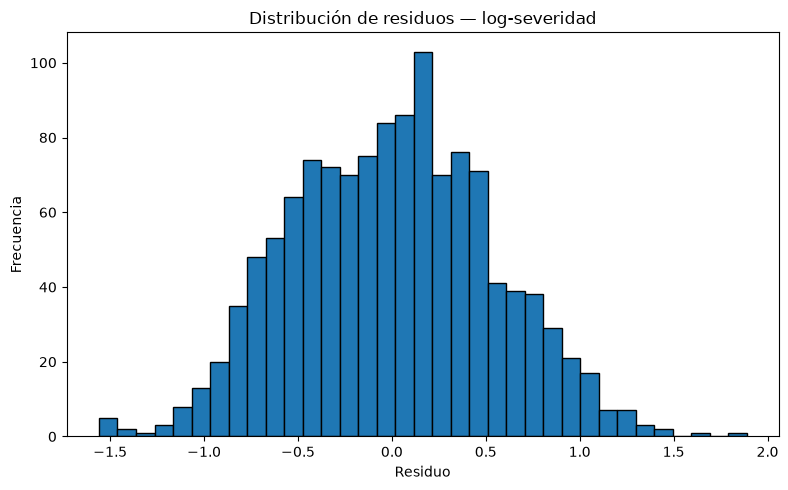

In [78]:
plt.figure(figsize=(8, 5))

plt.hist(
    residuals_log,
    bins=35,
    edgecolor="black"
)

plt.title("Distribución de residuos — log-severidad")
plt.xlabel("Residuo")
plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()

In [79]:
print(
    f"Media residuos: "
    f"{residuals_log.mean():.4f}"
)

print(
    f"Asimetría residuos: "
    f"{pd.Series(residuals_log).skew():.4f}"
)

print(
    f"Desviación estándar: "
    f"{residuals_log.std():.4f}"
)

Media residuos: 0.0000
Asimetría residuos: 0.0599
Desviación estándar: 0.5344


### Conclusión del ajuste en escala logarítmica

Los resultados respaldan la utilización de una regresión sobre
`log(severidad)`.

Los residuos presentan una distribución aproximadamente simétrica y compatible
con Normalidad, mientras que los coeficientes recuperan relaciones muy
similares a las obtenidas mediante el GLM Gamma.

La comparación de las retransfomaciones muestra además la importancia de
corregir el sesgo generado por la función exponencial. Una retransfomación
directa subestima considerablemente la severidad media, mientras que tanto la
corrección Lognormal como el estimador de Duan producen valores muy próximos a
la media observada.

Para la evaluación predictiva posterior se utilizará la corrección mediante
Duan Smearing.

### 4.6 Evaluación out-of-sample de log-severidad

In [80]:
pred_test_sev_log = pred_test_smearing
pred_train_sev_log = pred_train_smearing

#### 4.6.1 Calibración agregada

El modelo de log-severidad con corrección de Duan presenta una buena calibración
agregada.

En entrenamiento, la severidad media observada es aproximadamente $12,507,
mientras que la predicción media es $12,493, equivalente a una diferencia de
apenas -0.11%.

En la muestra de prueba, la severidad media observada es aproximadamente
$12,754 y la predicha $12,663, lo que representa una ligera subestimación de
aproximadamente -0.71%.

Estos resultados confirman que la corrección mediante Duan Smearing permite
retransformar adecuadamente las predicciones desde la escala logarítmica y
recuperar el nivel medio de severidad en la escala monetaria

In [81]:
logsev_calibration = pd.DataFrame({
    "Muestra": ["Train", "Test"],
    "Severidad observada": [
        y_train_sev.mean(),
        y_test_sev.mean()
    ],
    "Severidad predicha": [
        pred_train_sev_log.mean(),
        pred_test_sev_log.mean()
    ]
})

logsev_calibration["Diferencia relativa"] = (
    logsev_calibration["Severidad predicha"]
    / logsev_calibration["Severidad observada"]
    - 1
)

logsev_calibration

,Muestra,Severidad observada,Severidad predicha,Diferencia relativa
0,Train,12506.716444,12492.995250,-0.001097
1,Test,12753.534055,12663.209774,-0.007082


#### 4.6.2 MAE y RMSE contra el modelo baseline

El modelo de log-severidad presenta una mejora considerable respecto al
baseline que asigna la misma severidad esperada a todos los siniestros.

El MAE disminuye de aproximadamente $6,870 a $5,678, equivalente a una mejora
de 17.35%, mientras que el RMSE disminuye de $10,308 a $8,807, representando
una mejora aproximada de 14.56%.

El desempeño es ligeramente superior al obtenido mediante el GLM Gamma.
Sin embargo, las diferencias entre ambos modelos son muy pequeñas: el modelo
logarítmico reduce el MAE en aproximadamente $11 y el RMSE en aproximadamente
$15 adicionales respecto al Gamma.

Por lo tanto, ambos modelos presentan una capacidad predictiva prácticamente
equivalente frente a las severidades observadas.

In [82]:
logsev_metrics = regression_metrics(
    y_test_sev,
    pred_test_sev_log
)

severity_model_metrics = pd.DataFrame(
    [
        baseline_severity_metrics,
        gamma_metrics,
        logsev_metrics
    ],
    index=[
        "Baseline media",
        "GLM Gamma",
        "Log-severidad + Duan"
    ]
)

severity_model_metrics

,MAE,RMSE
Baseline media,6869.537765,10308.071382
GLM Gamma,5689.121329,8821.826163
Log-severidad + Duan,5677.705139,8807.103748


In [83]:
log_mae_improvement = relative_improvement(
    baseline_severity_metrics["MAE"],
    logsev_metrics["MAE"]
)

log_rmse_improvement = relative_improvement(
    baseline_severity_metrics["RMSE"],
    logsev_metrics["RMSE"]
)

print(
    f"Mejora MAE vs baseline: "
    f"{log_mae_improvement:.2%}"
)

print(
    f"Mejora RMSE vs baseline: "
    f"{log_rmse_improvement:.2%}"
)

Mejora MAE vs baseline: 17.35%
Mejora RMSE vs baseline: 14.56%


#### 4.6.3 Gamma deviance como métrica común

La log-severidad obtiene una Gamma deviance de aproximadamente 0.3157 frente
a 0.3172 del GLM Gamma.

Ambos modelos mejoran considerablemente respecto al baseline, cuya deviance es
0.4684. La log-severidad consigue una reducción relativa de aproximadamente
32.61%, frente a 32.29% del Gamma.

Aunque la log-severidad obtiene nuevamente el menor valor, la diferencia entre
ambos modelos es reducida. Esto refuerza la conclusión de que su desempeño
predictivo sobre las realizaciones observadas es prácticamente equivalente.

In [84]:
logsev_gamma_deviance = mean_gamma_deviance(
    y_test_sev,
    pred_test_sev_log
)

logsev_deviance_reduction = relative_improvement(
    gamma_deviance_baseline,
    logsev_gamma_deviance
)

print(
    f"Gamma Deviance - Baseline: "
    f"{gamma_deviance_baseline:.4f}"
)

print(
    f"Gamma Deviance - GLM Gamma: "
    f"{gamma_deviance_model:.4f}"
)

print(
    f"Gamma Deviance - Log-severidad: "
    f"{logsev_gamma_deviance:.4f}"
)

print(
    f"Reducción relativa Log-severidad: "
    f"{logsev_deviance_reduction:.2%}"
)

Gamma Deviance - Baseline: 0.4684
Gamma Deviance - GLM Gamma: 0.3172
Gamma Deviance - Log-severidad: 0.3157
Reducción relativa Log-severidad: 32.61%


#### 4.6.4 Calibración por quintiles

La calibración por quintiles muestra que el modelo de log-severidad discrimina
correctamente entre niveles de riesgo.

La severidad predicha aumenta progresivamente desde aproximadamente $7,451
en el primer quintil hasta $19,962 en el quintil de mayor riesgo. La severidad
observada presenta también una tendencia creciente, desde aproximadamente
$7,666 hasta $21,806.

La principal desviación se encuentra nuevamente en el tercer quintil, donde el
modelo sobreestima la severidad observada. En los dos quintiles superiores se
observa cierta subestimación, especialmente en el grupo de mayor riesgo.

Estas diferencias son similares a las observadas con el GLM Gamma y deben
interpretarse considerando que cada grupo contiene solamente alrededor de
63 siniestros y que la severidad presenta una elevada variabilidad individual.

En términos generales, el modelo presenta una buena capacidad de discriminación
y una calibración razonable a lo largo de la distribución del riesgo.

In [85]:
logsev_calibration_groups = calibration_by_quantile(
    y_test_sev,
    pred_test_sev_log,
    n_quantiles=5
)

logsev_calibration_groups

,grupo_riesgo,observado_medio,predicho_medio,observaciones
0,"(5565.418, 8488.518]",7666.349899,7451.285559,63
1,"(8488.518, 10612.963]",9179.659569,9601.525935,63
2,"(10612.963, 12691.173]",9748.979407,11616.044078,63
3,"(12691.173, 16895.559]",15366.574145,14685.483843,63
4,"(16895.559, 24224.071]",21806.107253,19961.709456,63


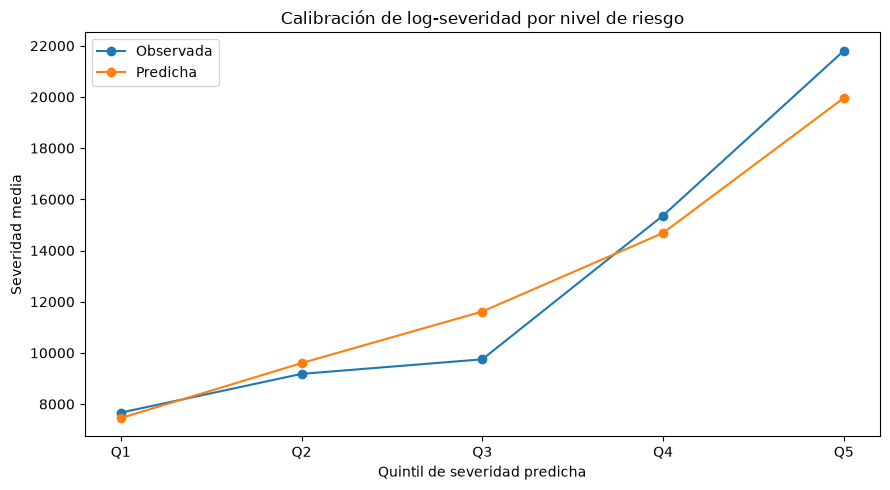

In [86]:
x = np.arange(
    len(logsev_calibration_groups)
)

plt.figure(figsize=(9, 5))

plt.plot(
    x,
    logsev_calibration_groups["observado_medio"],
    marker="o",
    label="Observada"
)

plt.plot(
    x,
    logsev_calibration_groups["predicho_medio"],
    marker="o",
    label="Predicha"
)

plt.xticks(
    x,
    [f"Q{i}" for i in range(1, len(x) + 1)]
)

plt.xlabel("Quintil de severidad predicha")
plt.ylabel("Severidad media")
plt.title(
    "Calibración de log-severidad por nivel de riesgo"
)

plt.legend()
plt.tight_layout()
plt.show()

### 4.7 Evaluación contra la severidad verdadera (*oracle*)

La evaluación contra la severidad esperada verdadera produce un resultado
ligeramente diferente al obtenido contra las realizaciones observadas.

El modelo de log-severidad obtiene un MAE *oracle* de aproximadamente $706 y un
RMSE de $1,068, con una correlación de 0.9812 entre la severidad verdadera y la
estimada.

Estos resultados muestran que el modelo recupera con elevada precisión la
estructura subyacente de la severidad.

Sin embargo, el GLM Gamma presenta errores *oracle* ligeramente inferiores:
un MAE de aproximadamente $697 y un RMSE de $1,044, además de una correlación
ligeramente superior de 0.9826.

Por tanto, aunque la log-severidad presenta métricas marginalmente mejores
contra las realizaciones observadas, el Gamma recupera ligeramente mejor la
verdadera esperanza condicional de la severidad.


In [87]:
oracle_logsev_metrics = regression_metrics(
    severity_true_test,
    pred_test_sev_log
)

oracle_logsev_corr = np.corrcoef(
    severity_true_test,
    pred_test_sev_log
)[0, 1]

print(
    f"Oracle MAE: "
    f"${oracle_logsev_metrics['MAE']:,.2f}"
)

print(
    f"Oracle RMSE: "
    f"${oracle_logsev_metrics['RMSE']:,.2f}"
)

print(
    f"Correlación oracle: "
    f"{oracle_logsev_corr:.4f}"
)

Oracle MAE: $705.66
Oracle RMSE: $1,068.39
Correlación oracle: 0.9812


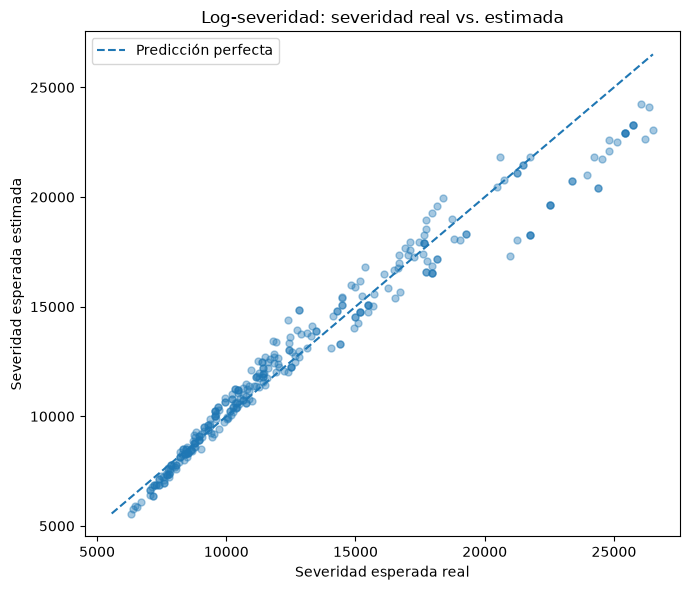

In [88]:
plt.figure(figsize=(7, 6))

plt.scatter(
    severity_true_test,
    pred_test_sev_log,
    alpha=0.4,
    s=25
)

min_val = min(
    severity_true_test.min(),
    pred_test_sev_log.min()
)

max_val = max(
    severity_true_test.max(),
    pred_test_sev_log.max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    label="Predicción perfecta"
)

plt.xlabel("Severidad esperada real")
plt.ylabel("Severidad esperada estimada")

plt.title(
    "Log-severidad: severidad real vs. estimada"
)

plt.legend()
plt.tight_layout()
plt.show()

### 4.8 Comparación final Gamma vs log-severidad

El GLM Gamma y la regresión sobre log-severidad presentan desempeños muy
similares.

La log-severidad obtiene valores marginalmente inferiores de MAE, RMSE y Gamma
deviance sobre las severidades observadas. Sin embargo, las diferencias son
muy pequeñas y no representan una mejora predictiva sustancial.

Al evaluar ambos modelos contra la severidad esperada verdadera del DGP, el
GLM Gamma presenta ligeramente menores errores y una correlación superior.

Además, existen diferencias prácticas entre ambas estrategias. El GLM Gamma
modela directamente:

$$
E[Z\mid X],
$$

que es precisamente la cantidad necesaria para calcular la prima pura.

En cambio, la regresión sobre log-severidad modela inicialmente:

$$
E[\log Z\mid X]
$$

y requiere posteriormente un procedimiento de retransfomación para recuperar
la esperanza en escala monetaria. Una retransfomación directa mediante la
función exponencial genera una subestimación debido a la desigualdad de Jensen,
por lo que fue necesario utilizar una corrección mediante Duan Smearing.

Dado que ambos modelos presentan un desempeño predictivo prácticamente
equivalente, pero el Gamma ofrece una estimación directa de la esperanza
condicional, una interpretación más sencilla y una recuperación ligeramente
superior de la función *oracle*, se conservará el GLM Gamma como modelo
estadístico principal de severidad.

La regresión Lognormal se mantiene como una alternativa estadística válida y
como evidencia de la importancia de tratar adecuadamente el sesgo de
retransfomación.

In [89]:
severity_comparison = pd.DataFrame({
    "Modelo": [
        "GLM Gamma",
        "Log-severidad + Duan"
    ],

    "MAE test": [
        gamma_metrics["MAE"],
        logsev_metrics["MAE"]
    ],

    "RMSE test": [
        gamma_metrics["RMSE"],
        logsev_metrics["RMSE"]
    ],

    "Gamma deviance": [
        gamma_deviance_model,
        logsev_gamma_deviance
    ],

    "Oracle MAE": [
        oracle_severity_metrics["MAE"],
        oracle_logsev_metrics["MAE"]
    ],

    "Oracle RMSE": [
        oracle_severity_metrics["RMSE"],
        oracle_logsev_metrics["RMSE"]
    ],

    "Oracle correlation": [
        oracle_severity_corr,
        oracle_logsev_corr
    ]
})

severity_comparison

,Modelo,MAE test,RMSE test,Gamma deviance,Oracle MAE,Oracle RMSE,Oracle correlation
0,GLM Gamma,5689.121329,8821.826163,0.317156,696.646021,1043.530463,0.982558
1,Log-severidad + Duan,5677.705139,8807.103748,0.315653,705.662194,1068.387468,0.981217


## 5. Prima pura mediante Frecuencia × Severidad

Una vez construidos los modelos de frecuencia y severidad, ambas componentes
pueden combinarse para estimar el costo esperado de cada póliza.

Bajo el supuesto de independencia condicional entre frecuencia y severidad:

$$
E[S_i\mid X_i]
=
E[N_i\mid X_i]
E[Z_i\mid X_i].
$$

Por tanto, la prima pura estimada mediante el enfoque clásico de frecuencia
por severidad es:

$$
\widehat{PP}_i
=
\hat{\lambda}_i
\widehat{E[Z_i\mid X_i]}.
$$

Para la frecuencia se utilizará el GLM Poisson seleccionado previamente,
mientras que para la severidad se utilizará el GLM Gamma reducido.

Las predicciones se calcularán para todas las pólizas de la muestra de prueba,
independientemente de que hayan presentado o no un siniestro durante el período
observado.

### 5.1 Predicción de las dos componentes

In [90]:
for data in [df_train, df_test]:

    data["zona_cat"] = data["zona"].map({
        1: "Muy bajo",
        2: "Bajo",
        3: "Medio",
        4: "Alto",
        5: "Muy alto"
    })

    data["cobertura_cat"] = data["cobertura"].map({
        0: "Limitada",
        1: "RC",
        2: "Amplia"
    })

    data["tipo_uso_cat"] = data["tipo_uso"].map({
        0: "Particular",
        1: "Transporte privado",
        2: "Carga comercial"
    })

**Frecuencia:**

In [91]:
pred_train_freq = poisson_2.predict(df_train)
pred_test_freq = poisson_2.predict(df_test)

**Severidad:**

In [92]:
pred_train_sev = gamma_final.predict(df_train)
pred_test_sev = gamma_final.predict(df_test)

**Prima Pura**

In [94]:
pred_train_pp_fs = (
    pred_train_freq
    * pred_train_sev
)

pred_test_pp_fs = (
    pred_test_freq
    * pred_test_sev
)

### 5.2 Calibración agregada.

La combinación del modelo Poisson de frecuencia y el GLM Gamma de severidad
produce una prima pura media cercana al costo agregado observado.

En entrenamiento, el costo observado promedio es aproximadamente $1,937 por
póliza, mientras que la prima pura predicha es $1,929, equivalente a una
diferencia relativa de apenas -0.42%.

En la muestra de prueba, el costo observado promedio es aproximadamente $2,009
y la prima pura predicha $1,901, lo que representa una diferencia relativa de
-5.38%.

Por tanto, el modelo presenta una ligera subestimación agregada en la muestra
de prueba.

Sin embargo, esta diferencia debe interpretarse considerando que el costo
observado es una realización aleatoria del proceso de siniestralidad y no la
prima pura verdadera. La muestra de prueba contiene únicamente 2,000 pólizas,
por lo que diferencias entre el costo observado y su esperanza son esperables
incluso bajo un modelo correctamente especificado.

In [95]:
pp_calibration = pd.DataFrame({
    "Muestra": ["Train", "Test"],

    "Costo observado medio": [
        df_train["costo_siniestros"].mean(),
        df_test["costo_siniestros"].mean()
    ],

    "Prima pura predicha media": [
        pred_train_pp_fs.mean(),
        pred_test_pp_fs.mean()
    ]
})

pp_calibration["Diferencia relativa"] = (
    pp_calibration["Prima pura predicha media"]
    / pp_calibration["Costo observado medio"]
    - 1
)

pp_calibration

,Muestra,Costo observado medio,Prima pura predicha media,Diferencia relativa
0,Train,1936.977709,1928.867017,-0.004187
1,Test,2008.681614,1900.543067,-0.053836


### 5.3 Baseline de prima pura

El enfoque Frecuencia × Severidad mejora las predicciones respecto a un
baseline que asigna a todas las pólizas el mismo costo esperado.

El MAE disminuye de aproximadamente $3,381 a $3,184, equivalente a una mejora
de 5.81%. Por su parte, el RMSE disminuye de aproximadamente $6,650 a $6,388,
lo que representa una mejora de 3.95%.

Las mejoras son más moderadas que las observadas al modelar severidad de manera
aislada. Esto es esperable porque el costo agregado combina dos fuentes de
variabilidad aleatoria: el número de siniestros y el costo de cada uno de ellos.

Una póliza con una prima pura elevada puede no registrar ningún siniestro
durante el período observado, mientras que otra póliza con el mismo riesgo
esperado puede experimentar una pérdida considerable.

Por esta razón, MAE y RMSE contra el costo observado miden tanto el error del
modelo como la variabilidad aleatoria inherente al proceso de siniestralidad.

In [96]:
baseline_pp = np.full(
    len(df_test),
    df_train["costo_siniestros"].mean()
)

In [97]:
y_test_cost = df_test["costo_siniestros"]

baseline_pp_metrics = regression_metrics(
    y_test_cost,
    baseline_pp
)

fs_metrics = regression_metrics(
    y_test_cost,
    pred_test_pp_fs
)

pp_metrics = pd.DataFrame(
    [
        baseline_pp_metrics,
        fs_metrics
    ],
    index=[
        "Baseline media",
        "Poisson × Gamma"
    ]
)

pp_metrics

,MAE,RMSE
Baseline media,3380.693184,6650.283158
Poisson × Gamma,3184.319010,6387.810262


In [98]:
pp_mae_improvement = relative_improvement(
    baseline_pp_metrics["MAE"],
    fs_metrics["MAE"]
)

pp_rmse_improvement = relative_improvement(
    baseline_pp_metrics["RMSE"],
    fs_metrics["RMSE"]
)

print(
    f"Mejora MAE: "
    f"{pp_mae_improvement:.2%}"
)

print(
    f"Mejora RMSE: "
    f"{pp_rmse_improvement:.2%}"
)

Mejora MAE: 5.81%
Mejora RMSE: 3.95%


### 5.4 Calibración por nivel de prima pura

La segmentación por deciles muestra que la prima pura estimada discrimina
claramente entre pólizas de distintos niveles de riesgo. La predicción media
aumenta progresivamente desde aproximadamente $514 por póliza en el primer
decil hasta $5,447 en el décimo.

Los costos observados presentan una tendencia general creciente, aunque con
fluctuaciones importantes entre algunos deciles. Por ejemplo, el costo
observado disminuye temporalmente en determinados grupos intermedios a pesar
del incremento de la prima pura estimada.

Este comportamiento no implica necesariamente una mala ordenación del riesgo.
Cada decil contiene solamente 200 pólizas y el costo agregado presenta una
gran concentración en cero junto con pérdidas individuales de elevada
magnitud. Como consecuencia, unos pocos siniestros grandes pueden modificar
considerablemente el costo promedio de un grupo.

El decil de mayor riesgo resulta particularmente informativo: el modelo estima
una prima pura promedio de aproximadamente $5,447 y el costo observado alcanza
aproximadamente $6,845, claramente superior al de los segmentos de menor riesgo.

En conjunto, el modelo muestra capacidad para segmentar el portafolio de acuerdo
con el riesgo esperado, aunque la elevada variabilidad del costo observado
dificulta evaluar la calibración mediante grupos relativamente pequeños.

In [99]:
pp_calibration_groups = calibration_by_quantile(
    y_test_cost,
    pred_test_pp_fs,
    n_quantiles=10
)

pp_calibration_groups

,grupo_riesgo,observado_medio,predicho_medio,observaciones
0,"(228.621, 635.839]",752.375435,514.224565,200
1,"(635.839, 837.665]",923.027604,733.060034,200
2,"(837.665, 1015.868]",664.090416,930.988462,200
3,"(1015.868, 1230.607]",1127.727321,1121.083635,200
4,"(1230.607, 1442.003]",1307.661017,1331.487699,200
5,"(1442.003, 1734.783]",1467.984291,1580.821943,200
6,"(1734.783, 2105.922]",1824.313601,1916.486913,200
7,"(2105.922, 2652.987]",2966.402328,2367.065880,200
8,"(2652.987, 3557.0]",2207.885409,3063.199853,200
9,"(3557.0, 16980.913]",6845.348713,5447.011686,200


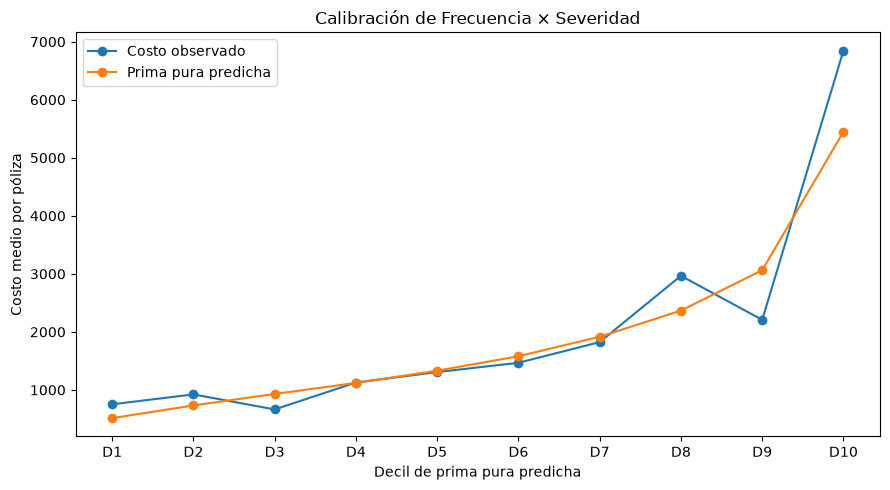

In [100]:
x = np.arange(
    len(pp_calibration_groups)
)

plt.figure(figsize=(9, 5))

plt.plot(
    x,
    pp_calibration_groups["observado_medio"],
    marker="o",
    label="Costo observado"
)

plt.plot(
    x,
    pp_calibration_groups["predicho_medio"],
    marker="o",
    label="Prima pura predicha"
)

plt.xticks(
    x,
    [f"D{i}" for i in range(1, len(x) + 1)]
)

plt.xlabel("Decil de prima pura predicha")
plt.ylabel("Costo medio por póliza")

plt.title(
    "Calibración de Frecuencia × Severidad"
)

plt.legend()
plt.tight_layout()
plt.show()

### 5.5 Evaluación contra la prima pura verdadera (*oracle*)

Debido al carácter sintético del experimento, se conoce para cada póliza la
verdadera esperanza condicional del costo agregado:

$$
PP_i^{real}=E[S_i\mid X_i].
$$

Al comparar esta cantidad con la prima pura estimada mediante
Poisson × Gamma, se obtiene:

- MAE *oracle*: aproximadamente $198;
- RMSE *oracle*: aproximadamente $288;
- correlación entre prima pura real y estimada: 0.9847.

Estos resultados son considerablemente mejores que los obtenidos al comparar
el modelo contra el costo efectivamente observado.

La diferencia evidencia nuevamente que gran parte del error frente al costo
realizado corresponde a variabilidad aleatoria y no a una incapacidad del
modelo para identificar el riesgo subyacente.

La elevada correlación y la concentración de las observaciones alrededor de
la línea de predicción perfecta muestran que el enfoque Frecuencia × Severidad
recupera con elevada precisión la verdadera estructura de prima pura utilizada
por el proceso generador.

In [101]:
pp_true_test = df_test[
    "prima_pura_real"
]

In [102]:
oracle_pp_metrics = regression_metrics(
    pp_true_test,
    pred_test_pp_fs
)

oracle_pp_corr = np.corrcoef(
    pp_true_test,
    pred_test_pp_fs
)[0, 1]

print(
    f"Oracle MAE: "
    f"${oracle_pp_metrics['MAE']:,.2f}"
)

print(
    f"Oracle RMSE: "
    f"${oracle_pp_metrics['RMSE']:,.2f}"
)

print(
    f"Correlación oracle: "
    f"{oracle_pp_corr:.4f}"
)

Oracle MAE: $198.19
Oracle RMSE: $287.66
Correlación oracle: 0.9847


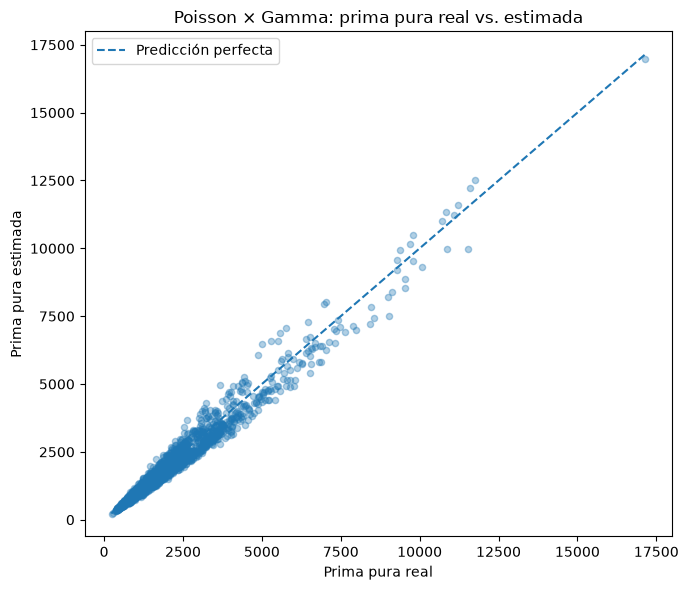

In [103]:
plt.figure(figsize=(7, 6))

plt.scatter(
    pp_true_test,
    pred_test_pp_fs,
    alpha=0.35,
    s=20
)

min_val = min(
    pp_true_test.min(),
    pred_test_pp_fs.min()
)

max_val = max(
    pp_true_test.max(),
    pred_test_pp_fs.max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    label="Predicción perfecta"
)

plt.xlabel("Prima pura real")
plt.ylabel("Prima pura estimada")

plt.title(
    "Poisson × Gamma: prima pura real vs. estimada"
)

plt.legend()
plt.tight_layout()
plt.show()

### 5.6 Descomposición del error de prima pura

La disponibilidad de las variables *oracle* permite estudiar qué componente
contribuye en mayor medida al error final de la prima pura.

Cuando frecuencia y severidad son estimadas, el MAE frente a la prima pura
verdadera es aproximadamente $198.

Al sustituir únicamente la severidad estimada por la severidad verdadera,
manteniendo la frecuencia estimada, el MAE disminuye a aproximadamente $168.

Por otro lado, al utilizar la frecuencia verdadera y mantener la severidad
estimada mediante Gamma, el MAE disminuye hasta aproximadamente $100.

Estos resultados indican que, dentro del enfoque actual, el modelo de frecuencia
constituye la principal fuente de error en la estimación de la prima pura.

El resultado es consistente con los análisis anteriores: el modelo Gamma
recuperó con elevada precisión la severidad esperada, mientras que la
frecuencia presenta una mayor dificultad predictiva debido tanto a su estructura
como a la menor cantidad de información disponible en una variable de conteo
con fuerte concentración en cero.

Los errores de ambas componentes no son estrictamente aditivos, ya que la prima
pura se obtiene mediante su producto. Sin embargo, este experimento permite
identificar que futuras mejoras sobre la modelación de frecuencia presentan un
mayor margen potencial para reducir el error final.

In [104]:
pp_both_estimated = (
    pred_test_freq
    * pred_test_sev
)

In [105]:
pp_freq_error_only = (
    pred_test_freq
    * df_test["severidad_esperada_real"]
)

In [106]:
pp_sev_error_only = (
    df_test["lambda_real"]
    * pred_test_sev
)

In [107]:
pp_error_decomposition = pd.DataFrame({
    "Modelo": [
        "Frecuencia y severidad estimadas",
        "Frecuencia estimada + severidad oracle",
        "Frecuencia oracle + severidad estimada"
    ],

    "MAE oracle": [
        mean_absolute_error(
            pp_true_test,
            pp_both_estimated
        ),

        mean_absolute_error(
            pp_true_test,
            pp_freq_error_only
        ),

        mean_absolute_error(
            pp_true_test,
            pp_sev_error_only
        )
    ],

    "RMSE oracle": [
        np.sqrt(mean_squared_error(
            pp_true_test,
            pp_both_estimated
        )),

        np.sqrt(mean_squared_error(
            pp_true_test,
            pp_freq_error_only
        )),

        np.sqrt(mean_squared_error(
            pp_true_test,
            pp_sev_error_only
        ))
    ]
})

pp_error_decomposition

,Modelo,MAE oracle,RMSE oracle
0,Frecuencia y severidad estimadas,198.187975,287.664493
1,Frecuencia estimada + severidad oracle,167.539550,237.930259
2,Frecuencia oracle + severidad estimada,99.626906,177.091300


### Conclusión del enfoque Frecuencia × Severidad

La combinación del GLM Poisson de frecuencia y el GLM Gamma de severidad
constituye un modelo estadístico completo e interpretable para estimar la prima
pura de cada póliza.

Frente al costo observado, el modelo mejora moderadamente respecto a un baseline
que asigna el mismo costo esperado a todo el portafolio. La magnitud relativamente
pequeña de esta mejora se explica por la elevada variabilidad aleatoria del
costo agregado a nivel individual.

Sin embargo, al evaluar las predicciones contra la prima pura verdadera del
DGP, el modelo obtiene un MAE cercano a $198, un RMSE de aproximadamente $288
y una correlación de 0.985, mostrando una elevada capacidad para recuperar la
estructura real del riesgo.

La descomposición del error indica además que el componente de frecuencia
representa actualmente una mayor fuente de error que el modelo de severidad.

El enfoque Frecuencia × Severidad proporciona adicionalmente una ventaja
importante de interpretabilidad: permite identificar si una característica
incrementa el riesgo debido a una mayor ocurrencia de siniestros, una mayor
magnitud de las pérdidas o una combinación de ambos mecanismos.

Este modelo se conservará como el principal baseline actuarial para la
comparación posterior con estrategias de modelación directa y modelos de mayor
complejidad.

## 6. GLM Tweedie para el costo agregado

Como alternativa al enfoque Frecuencia × Severidad, se ajustará un modelo
Tweedie directamente sobre el costo agregado por póliza.

La variable `costo_siniestros` presenta dos características principales:

- una elevada concentración de observaciones iguales a cero;
- valores positivos continuos y asimétricos para las pólizas con pérdidas.

Para valores del parámetro de potencia:

$$
1 < p < 2,
$$

la distribución Tweedie puede representarse como una distribución compuesta
Poisson-Gamma, lo que permite modelar simultáneamente una masa en cero y
pérdidas positivas continuas.

Se supone:

$$
S_i\mid X_i \sim Tweedie(\mu_i,\phi,p)
$$

con:

$$
Var(S_i\mid X_i)=\phi\mu_i^p.
$$

Se utilizará un enlace logarítmico:

$$
\log(\mu_i)=X_i^\top\beta,
$$

de manera que:

$$
E[S_i\mid X_i]
=
\exp(X_i^\top\beta).
$$

A diferencia del enfoque Frecuencia × Severidad, este modelo estima directamente
la prima pura sin descomponer el costo esperado en sus dos componentes.

### 6.1 Definición de variables

In [112]:
formula_tweedie = """
costo_siniestros ~
edad_c +
edad_c2 +
anios_vehiculo +
C(zona_cat) +
C(cobertura_cat) +
historial_siniestros +
C(tipo_uso_cat)
"""

### 6.2 Inicializamos el parámetro de potencia $p$

In [113]:
TWEEDIE_POWER = 1.5

In [114]:
tweedie_1 = smf.glm(
    formula=formula_tweedie,
    data=df_train,
    family=sm.families.Tweedie(
        var_power=TWEEDIE_POWER,
        link=sm.families.links.Log()
    )
).fit()

print(tweedie_1.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:       costo_siniestros   No. Observations:                 8000
Model:                            GLM   Df Residuals:                     7987
Model Family:                 Tweedie   Df Model:                           12
Link Function:                    Log   Scale:                          379.36
Method:                          IRLS   Log-Likelihood:                -15135.
Date:              mar., 22 sep. 2026   Deviance:                   1.6385e+06
Time:                        16:46:56   Pearson chi2:                 3.03e+06
No. Iterations:                    13   Pseudo R-squ. (CS):            0.05750
Covariance Type:            nonrobust                                         
                                            coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

### 6.3 Interpretación de los coeficientes.

El modelo Tweedie recupera efectos consistentes con los patrones encontrados
previamente al analizar frecuencia y severidad por separado.

El historial de siniestros presenta uno de los efectos más importantes: cada
siniestro adicional en el historial se asocia con un incremento aproximado de
42.5% en el costo esperado por póliza.

La antigüedad del vehículo presenta también un efecto positivo: cada año
adicional está asociado con un incremento aproximado de 3.2% en el costo
esperado.

Zona, cobertura y tipo de uso presentan diferencias significativas entre
categorías. Los efectos son particularmente pronunciados para zona y cobertura,
lo que resulta consistente con el análisis anterior, donde estas variables
afectaban simultáneamente la frecuencia y/o la severidad.

La edad mantiene una estructura no lineal. Aunque el término lineal centrado no
resulta significativo al 5%, el término cuadrático es negativo y
estadísticamente significativo. Por principio jerárquico, ambos términos se
conservan en el modelo.

En conjunto, el Tweedie combina dentro de una sola especificación relaciones que
en el enfoque Frecuencia × Severidad aparecían distribuidas entre dos modelos
diferentes.


In [115]:
tweedie_coef_table = pd.DataFrame({
    "coef": tweedie_1.params,
    "exp_coef": np.exp(tweedie_1.params),
    "change_pct": (
        np.exp(tweedie_1.params) - 1
    ) * 100,
    "p_value": tweedie_1.pvalues
})

tweedie_coef_table

,coef,exp_coef,change_pct,p_value
Intercept,8.067575,3189.358765,318835.876458,0.000000e+00
C(zona_cat)[T.Bajo],-0.602406,0.547493,-45.250698,2.386643e-08
C(zona_cat)[T.Medio],-0.354750,0.701349,-29.865096,7.969487e-04
C(zona_cat)[T.Muy alto],0.330199,1.391245,39.124469,6.594063e-04
C(zona_cat)[T.Muy bajo],-0.848030,0.428258,-57.174228,3.378798e-14
C(cobertura_cat)[T.Limitada],-0.843989,0.429992,-57.000801,6.782207e-24
C(cobertura_cat)[T.RC],-0.487889,0.613921,-38.607868,5.522633e-08
C(tipo_uso_cat)[T.Particular],-0.424051,0.654390,-34.560962,3.659834e-04
C(tipo_uso_cat)[T.Transporte privado],-0.350111,0.704610,-29.539006,3.588271e-03
edad_c,-0.003544,0.996462,-0.353764,9.571062e-02


### 6.3 Selección del parámetro $p$

El parámetro de potencia $p$ determina la relación entre la media y la
varianza de la distribución Tweedie:

$$
Var(Y\mid X)=\phi\mu^p.
$$

Para $1<p<2$, la distribución corresponde al caso compuesto
Poisson-Gamma, adecuado para variables que combinan una masa en cero con
valores positivos continuos.

Se ajustaron modelos para distintos valores de $p$ utilizando únicamente
datos de entrenamiento.

El perfil de log-likelihood alcanza su valor máximo alrededor de $p=1.3$,
lo que indica que esta región proporciona el mejor ajuste entre los valores
evaluados.

La Tweedie deviance calculada utilizando diferentes valores de `power` no se
utiliza directamente para seleccionar $p$, ya que al modificar este
parámetro también cambia la propia función de pérdida y, por tanto, sus
magnitudes no son directamente comparables entre modelos.

Por esta razón, la selección del parámetro se realizará mediante el perfil de
log-likelihood.

In [ ]:
from sklearn.model_selection import train_test_split

# Hacemos un split en train para validar la mejor selección del parámetro P

tweedie_fit_idx, tweedie_val_idx = train_test_split(
    df_train.index,
    test_size=0.20,
    random_state=SEED
)

tweedie_fit = df_train.loc[tweedie_fit_idx].copy()
tweedie_val = df_train.loc[tweedie_val_idx].copy()

print(len(tweedie_fit), len(tweedie_val))

6400 1600


In [117]:
powers = np.arange(
    1.1,
    2.0,
    0.1
)

In [118]:
from sklearn.metrics import mean_tweedie_deviance

results_power = []

for p in powers:

    model = smf.glm(
        formula=formula_tweedie,
        data=tweedie_fit,
        family=sm.families.Tweedie(
            var_power=p,
            link=sm.families.links.Log()
        )
    ).fit()

    pred_val = model.predict(
        tweedie_val
    )

    deviance = mean_tweedie_deviance(
        tweedie_val["costo_siniestros"],
        pred_val,
        power=p
    )

    results_power.append({
        "power": p,
        "deviance_validation": deviance,
        "loglik_train": model.llf,
        "scale": model.scale
    })

power_results = pd.DataFrame(
    results_power
)

power_results

,power,deviance_validation,loglik_train,scale
0,1.1,3438.823140,-12326.516559,7231.931059
1,1.2,1632.725496,-11862.401146,3439.605205
2,1.3,793.720205,-11849.835025,1644.033192
3,1.4,396.952581,-11960.762137,789.606267
4,1.5,205.752583,-12152.375332,381.030285
5,1.6,111.920678,-12443.040042,184.719089
6,1.7,65.411361,-12911.448120,89.955744
7,1.8,43.312085,-13811.766285,44.003079
8,1.9,38.500677,-16429.011716,21.620281


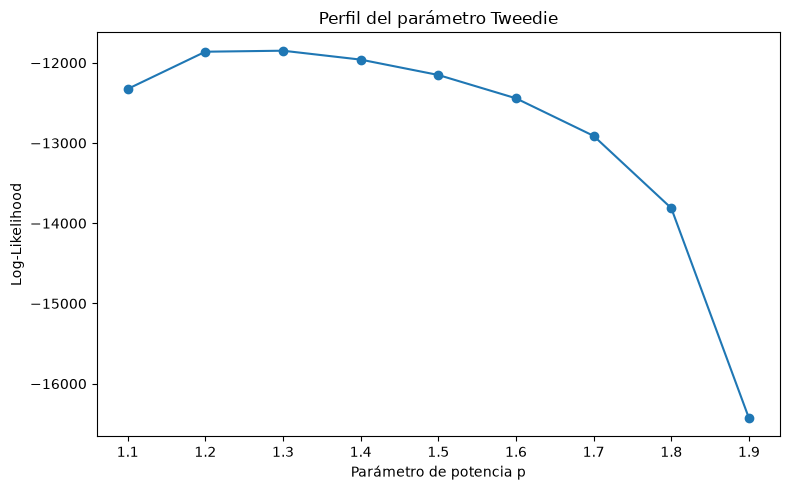

In [119]:
plt.figure(figsize=(8, 5))

plt.plot(
    power_results["power"],
    power_results["loglik_train"],
    marker="o"
)

plt.xlabel("Parámetro de potencia p")
plt.ylabel("Log-Likelihood")
plt.title("Perfil del parámetro Tweedie")

plt.tight_layout()
plt.show()

#### Busqueda más fina...

Se realizó una búsqueda más fina del parámetro de potencia Tweedie en el
intervalo cercano al máximo identificado previamente.

El perfil de log-likelihood alcanza su valor máximo en:

$$
p = 1.25.
$$

Los valores vecinos presentan ajustes muy similares, por lo que no se considera
necesario realizar una optimización más precisa.

En consecuencia, se fija $p=1.25$ como parámetro de potencia del modelo
Tweedie final.

In [121]:
fine_powers = np.arange(
    1.20,
    1.41,
    0.01
)

fine_results = []

for p in fine_powers:

    model = smf.glm(
        formula=formula_tweedie,
        data=tweedie_fit,
        family=sm.families.Tweedie(
            var_power=p,
            link=sm.families.links.Log()
        )
    ).fit()

    fine_results.append({
        "power": p,
        "loglik": model.llf,
        "scale": model.scale
    })

fine_power_results = pd.DataFrame(
    fine_results
)

fine_power_results.sort_values(
    "loglik",
    ascending=False
).head(10)

,power,loglik,scale
5,1.25,-11833.463822,2376.534994
6,1.26,-11833.877461,2207.472118
4,1.24,-11834.790765,2558.670904
7,1.27,-11835.856643,2050.536104
3,1.23,-11838.067971,2754.900563
8,1.28,-11839.254753,1904.849832
2,1.22,-11843.547694,2966.325156
9,1.29,-11843.948702,1769.600155
10,1.30,-11849.835025,1644.033192
1,1.21,-11851.535006,3194.132749


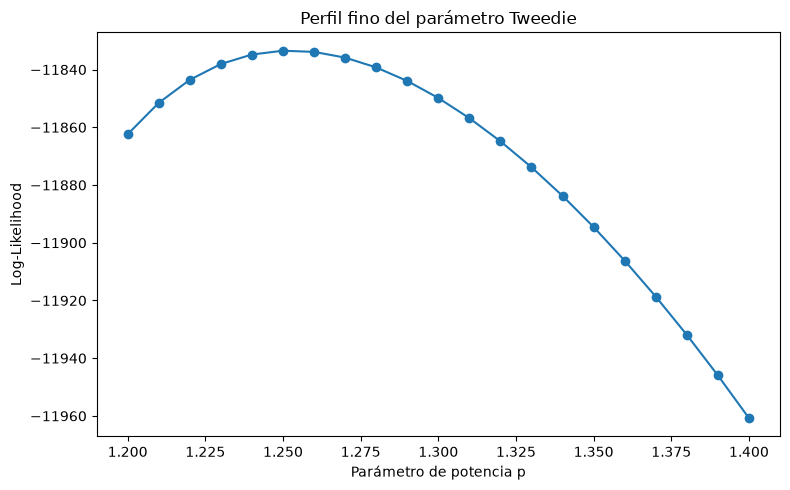

In [122]:
plt.figure(figsize=(8, 5))

plt.plot(
    fine_power_results["power"],
    fine_power_results["loglik"],
    marker="o"
)

plt.xlabel("Parámetro de potencia p")
plt.ylabel("Log-Likelihood")
plt.title("Perfil fino del parámetro Tweedie")

plt.tight_layout()
plt.show()

In [ ]:
best_row = fine_power_results.loc[
    fine_power_results["loglik"].idxmax()
]

best_row

power         1.250000
loglik   -11833.463822
scale      2376.534994
Name: 5, dtype: float64

In [133]:
TWEEDIE_POWER_FINAL = best_row["power"]

print(
    f"Power seleccionado: "
    f"{TWEEDIE_POWER_FINAL:.2f}"
)

Power seleccionado: 1.25


### 6.4 Ajuste del modelo

In [134]:
tweedie_final = smf.glm(
    formula=formula_tweedie,
    data=df_train,
    family=sm.families.Tweedie(
        var_power=TWEEDIE_POWER_FINAL,
        link=sm.families.links.Log()
    )
).fit()

print(tweedie_final.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:       costo_siniestros   No. Observations:                 8000
Model:                            GLM   Df Residuals:                     7987
Model Family:                 Tweedie   Df Model:                           12
Link Function:                    Log   Scale:                          2362.3
Method:                          IRLS   Log-Likelihood:                -14728.
Date:              mar., 22 sep. 2026   Deviance:                   9.0742e+06
Time:                        17:13:15   Pearson chi2:                 1.89e+07
No. Iterations:                    10   Pseudo R-squ. (CS):            0.06277
Covariance Type:            nonrobust                                         
                                            coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

In [126]:
pred_train_tweedie = tweedie_final.predict(df_train)
pred_test_tweedie = tweedie_final.predict(df_test)

### 6.5 Calibración agregada

El GLM Tweedie presenta una buena calibración agregada tanto en entrenamiento
como en prueba.

En la muestra de entrenamiento, el costo observado medio es aproximadamente
$1,937 por póliza y el costo predicho es $1,936, lo que representa una
diferencia relativa de apenas -0.06%.

En la muestra de prueba, el costo observado promedio es aproximadamente $2,009,
mientras que el modelo predice $1,907, equivalente a una diferencia relativa
de -5.06%.

Por tanto, el modelo presenta una ligera subestimación agregada en test.

Esta diferencia es similar a la observada con el enfoque Poisson × Gamma y debe
interpretarse considerando que el costo observado constituye una realización
aleatoria del proceso de siniestralidad y no la esperanza condicional verdadera.

In [127]:
tweedie_calibration = pd.DataFrame({
    "Muestra": ["Train", "Test"],
    "Costo observado medio": [
        df_train["costo_siniestros"].mean(),
        df_test["costo_siniestros"].mean()
    ],
    "Costo predicho medio": [
        pred_train_tweedie.mean(),
        pred_test_tweedie.mean()
    ]
})

tweedie_calibration["Diferencia relativa"] = (
    tweedie_calibration["Costo predicho medio"]
    / tweedie_calibration["Costo observado medio"]
    - 1
)

tweedie_calibration

,Muestra,Costo observado medio,Costo predicho medio,Diferencia relativa
0,Train,1936.977709,1935.745385,-0.000636
1,Test,2008.681614,1907.046412,-0.050598


### 6.6 MAE y RMSE contra baseline de prima pura

El GLM Tweedie mejora el desempeño respecto al baseline que asigna el mismo
costo esperado a todas las pólizas.

El MAE disminuye de aproximadamente $3,381 a $3,187, equivalente a una mejora
de 5.74%, mientras que el RMSE disminuye de $6,650 a $6,382, lo que representa
una mejora aproximada de 4.03%.

Los resultados son prácticamente equivalentes a los obtenidos mediante el
enfoque Poisson × Gamma.

Poisson × Gamma presenta un MAE ligeramente inferior, mientras que Tweedie
obtiene un RMSE marginalmente menor. Sin embargo, las diferencias son de muy
pequeña magnitud y no representan una ventaja predictiva relevante para ninguno
de los dos enfoques.

In [128]:
tweedie_metrics = regression_metrics(
    y_test_cost,
    pred_test_tweedie
)

pd.DataFrame(
    [
        baseline_pp_metrics,
        fs_metrics,
        tweedie_metrics
    ],
    index=[
        "Baseline media",
        "Poisson × Gamma",
        "GLM Tweedie"
    ]
)

,MAE,RMSE
Baseline media,3380.693184,6650.283158
Poisson × Gamma,3184.319010,6387.810262
GLM Tweedie,3186.569913,6382.115855


In [129]:
tweedie_mae_improvement = relative_improvement(
    baseline_pp_metrics["MAE"],
    tweedie_metrics["MAE"]
)

tweedie_rmse_improvement = relative_improvement(
    baseline_pp_metrics["RMSE"],
    tweedie_metrics["RMSE"]
)

print(f"Mejora MAE:  {tweedie_mae_improvement:.2%}")
print(f"Mejora RMSE: {tweedie_rmse_improvement:.2%}")

Mejora MAE:  5.74%
Mejora RMSE: 4.03%


### 6.7 Tweedie deviance

Utilizando el parámetro de potencia seleccionado \(p=1.25\) como función de
evaluación común, el baseline obtiene una Tweedie deviance de aproximadamente
1320.52.

Poisson × Gamma reduce este valor a aproximadamente 1162.83, mientras que el
GLM Tweedie obtiene 1161.79.

El Tweedie presenta la menor deviance, aunque la diferencia respecto al enfoque
Frecuencia × Severidad es muy reducida.

Por tanto, ambas estrategias representan de manera prácticamente equivalente
la distribución del costo agregado en la muestra de prueba.

In [130]:
tweedie_deviance_baseline = mean_tweedie_deviance(
    y_test_cost,
    baseline_pp,
    power=TWEEDIE_POWER_FINAL
)

tweedie_deviance_fs = mean_tweedie_deviance(
    y_test_cost,
    pred_test_pp_fs,
    power=TWEEDIE_POWER_FINAL
)

tweedie_deviance_model = mean_tweedie_deviance(
    y_test_cost,
    pred_test_tweedie,
    power=TWEEDIE_POWER_FINAL
)

print(f"Baseline:         {tweedie_deviance_baseline:.4f}")
print(f"Poisson × Gamma: {tweedie_deviance_fs:.4f}")
print(f"GLM Tweedie:     {tweedie_deviance_model:.4f}")

Baseline:         1320.5237
Poisson × Gamma: 1162.8329
GLM Tweedie:     1161.7898


### 6.8 Calibración por deciles

La segmentación por deciles muestra que el GLM Tweedie discrimina claramente
entre pólizas de distinto nivel de costo esperado.

La predicción promedio aumenta de manera progresiva desde aproximadamente $505
por póliza en el primer decil hasta $5,511 en el décimo.

El costo observado presenta una tendencia general creciente, aunque con
fluctuaciones relevantes entre determinados grupos intermedios.

Estas desviaciones son similares a las encontradas con Poisson × Gamma y se
explican parcialmente por la elevada variabilidad del costo agregado. Cada
decil contiene únicamente 200 pólizas, por lo que unos pocos siniestros de gran
magnitud pueden modificar significativamente su costo promedio.

El décimo decil concentra claramente los riesgos de mayor costo, con una
predicción promedio cercana a $5,511 y un costo observado de aproximadamente
$6,845.

En términos generales, el Tweedie presenta una buena capacidad para ordenar el
portafolio desde riesgos de menor hasta mayor costo esperado.

In [131]:
tweedie_calibration_groups = calibration_by_quantile(
    y_test_cost,
    pred_test_tweedie,
    n_quantiles=10
)

tweedie_calibration_groups

,grupo_riesgo,observado_medio,predicho_medio,observaciones
0,"(236.156, 624.141]",796.051525,504.860521,200
1,"(624.141, 828.62]",909.031003,722.958744,200
2,"(828.62, 1003.432]",586.747267,924.219890,200
3,"(1003.432, 1227.929]",1177.751304,1111.648019,200
4,"(1227.929, 1441.707]",1275.638842,1324.870828,200
5,"(1441.707, 1740.587]",1469.263095,1578.470542,200
6,"(1740.587, 2121.979]",1852.696650,1923.809196,200
7,"(2121.979, 2671.962]",3010.681606,2382.155144,200
8,"(2671.962, 3641.597]",2163.606131,3086.749684,200
9,"(3641.597, 16957.668]",6845.348713,5510.721555,200


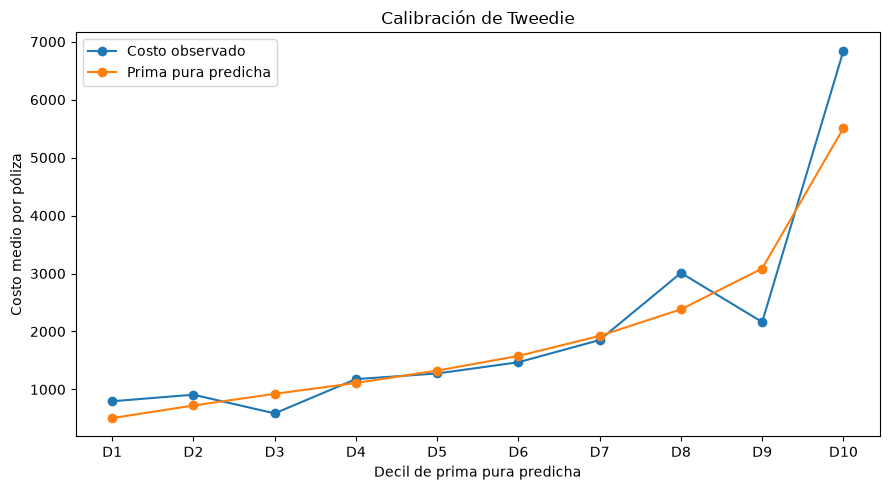

In [132]:
x = np.arange(
    len(tweedie_calibration_groups)
)

plt.figure(figsize=(9, 5))

plt.plot(
    x,
    tweedie_calibration_groups["observado_medio"],
    marker="o",
    label="Costo observado"
)

plt.plot(
    x,
    tweedie_calibration_groups["predicho_medio"],
    marker="o",
    label="Prima pura predicha"
)

plt.xticks(
    x,
    [f"D{i}" for i in range(1, len(x) + 1)]
)

plt.xlabel("Decil de prima pura predicha")
plt.ylabel("Costo medio por póliza")

plt.title(
    "Calibración de Tweedie"
)

plt.legend()
plt.tight_layout()
plt.show()

### 6.9 Evaluación contra la prima pura verdadera (*oracle*)

Al comparar las predicciones del GLM Tweedie con la prima pura verdadera del
proceso generador, se obtiene:

- MAE *oracle*: aproximadamente $191;
- RMSE *oracle*: aproximadamente $281;
- correlación entre prima pura verdadera y estimada: 0.9853.

Estos resultados indican que el Tweedie recupera con elevada precisión la
esperanza condicional del costo agregado.

La comparación con Poisson × Gamma muestra una pequeña ventaja para el Tweedie.
El enfoque Frecuencia × Severidad obtuvo un MAE de aproximadamente $198 y un
RMSE de $288, con una correlación de 0.9847.

Por tanto, el modelado directo mediante Tweedie recupera ligeramente mejor la
función verdadera de prima pura, aunque la diferencia entre ambos modelos es
pequeña.

In [135]:
oracle_tweedie_metrics = regression_metrics(
    pp_true_test,
    pred_test_tweedie
)

oracle_tweedie_corr = np.corrcoef(
    pp_true_test,
    pred_test_tweedie
)[0, 1]

print(
    f"Oracle MAE: "
    f"${oracle_tweedie_metrics['MAE']:,.2f}"
)

print(
    f"Oracle RMSE: "
    f"${oracle_tweedie_metrics['RMSE']:,.2f}"
)

print(
    f"Correlación oracle: "
    f"{oracle_tweedie_corr:.4f}"
)

Oracle MAE: $190.70
Oracle RMSE: $280.87
Correlación oracle: 0.9853


## 7. Comparación de estrategias estadísticas para prima pura

El enfoque Poisson × Gamma y el GLM Tweedie presentan un desempeño predictivo
muy similar.

Sobre el costo observado, Poisson × Gamma obtiene un MAE marginalmente inferior,
mientras que Tweedie presenta un RMSE y una Tweedie deviance ligeramente
menores. Las diferencias son, sin embargo, demasiado pequeñas para considerar
que uno de los modelos domina claramente al otro.

En la evaluación contra la prima pura verdadera, el Tweedie presenta una pequeña
ventaja, con menores valores de MAE y RMSE y una correlación ligeramente mayor.

Sin embargo, ambos enfoques presentan características conceptuales diferentes.

Poisson × Gamma permite descomponer el riesgo en:

$$
\text{Frecuencia} \times \text{Severidad},
$$
lo que proporciona una mayor interpretabilidad y permite identificar si un
factor modifica principalmente la probabilidad de ocurrencia de siniestros, su
magnitud o ambas componentes.

El Tweedie, en cambio, modela directamente:

$$
E[S\mid X],
$$
utilizando una sola especificación estadística capaz de representar
simultáneamente la masa en cero y los valores positivos del costo agregado.

Por tanto, el Tweedie ofrece una estrategia más compacta y obtiene una ligera
ventaja en recuperación de la prima pura verdadera, mientras que
Poisson × Gamma proporciona una interpretación actuarial más detallada.

Ambos modelos se conservarán como referencias estadísticas en la comparación
posterior con métodos de Machine Learning y Deep Learning.

In [137]:
statistical_pp_comparison = pd.DataFrame({
    "Modelo": [
        "Poisson × Gamma",
        "GLM Tweedie"
    ],
    "MAE test": [
        fs_metrics["MAE"],
        tweedie_metrics["MAE"]
    ],
    "RMSE test": [
        fs_metrics["RMSE"],
        tweedie_metrics["RMSE"]
    ],
    "Tweedie deviance": [
        tweedie_deviance_fs,
        tweedie_deviance_model
    ],
    "Oracle MAE": [
        oracle_pp_metrics["MAE"],
        oracle_tweedie_metrics["MAE"]
    ],
    "Oracle RMSE": [
        oracle_pp_metrics["RMSE"],
        oracle_tweedie_metrics["RMSE"]
    ],
    "Oracle correlation": [
        oracle_pp_corr,
        oracle_tweedie_corr
    ]
})

statistical_pp_comparison

,Modelo,MAE test,RMSE test,Tweedie deviance,Oracle MAE,Oracle RMSE,Oracle correlation
0,Poisson × Gamma,3184.319010,6387.810262,1162.832922,198.187975,287.664493,0.984688
1,GLM Tweedie,3186.569913,6382.115855,1161.789798,190.702458,280.870926,0.985267
